In [38]:
import pandas as pd
import numpy as np
import Metrica_Velocities as mvel
import importlib
import Metrica_IO as mio

importlib.reload(mio)


<module 'Metrica_IO' from 'd:\\HEC Paris\\M2\\Personal Project\\football-tactical-analysis\\Metrica_IO.py'>

In [2]:
# Define the data directory and game ID
DATADIR = "data"
GAME_ID = 2

# Load tracking and event data
tracking_home, tracking_away, events = mio.read_match_data(DATADIR, GAME_ID)

# Convert positions from Metrica units to meters
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


Reading team: home
Reading team: away


In [3]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y,ball_x,ball_y
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.08,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0.12,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.16,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.20,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,-46.3379,-0.84524,-12.19106,23.55792,-29.08852,5.87860,-24.22948,12.09788,...,NaN,NaN,-9.71278,24.17468,1.09392,-30.29672,-23.36028,9.04400,NaN,NaN
141153,2,5646.12,-46.3379,-0.84524,-12.19106,23.55792,-29.08852,5.87860,-24.22948,12.09788,...,NaN,NaN,-9.71278,24.17468,1.09286,-30.34568,-23.31046,9.03176,NaN,NaN
141154,2,5646.16,-46.3379,-0.84524,-12.19106,23.55792,-29.08852,5.87860,-24.22948,12.09788,...,NaN,NaN,-9.71278,24.17468,1.09074,-30.40348,-23.28714,9.02632,NaN,NaN


In [4]:
events

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.50,0.50,0.40,0.51
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,0.43,0.50,0.44,0.22
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,0.47,0.19,0.31,0.28
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,0.29,0.32,0.26,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,Away,BALL LOST,INTERCEPTION,2,140122,5604.88,140183,5607.32,Player21,NaN,0.54,0.77,0.29,0.24
1931,Home,CHALLENGE,AERIAL-LOST,2,140180,5607.20,140180,5607.20,Player1,NaN,0.31,0.30,NaN,NaN
1932,Away,CHALLENGE,AERIAL-LOST,2,140183,5607.32,140183,5607.32,Player24,NaN,0.32,0.30,NaN,NaN
1933,Home,RECOVERY,NaN,2,140211,5608.44,140211,5608.44,Player12,NaN,0.34,0.32,NaN,NaN


In [5]:
# Ensure all coordinates are in a single playing direction
tracking_home, tracking_away, events = mio.to_single_playing_direction(
    tracking_home, tracking_away, events
)


In [6]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y,ball_x,ball_y
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.08,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0.12,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.16,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.20,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.20564,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,NaN,NaN,9.71278,-24.17468,-1.09392,30.29672,23.36028,-9.04400,NaN,NaN
141153,2,5646.12,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,NaN,NaN,9.71278,-24.17468,-1.09286,30.34568,23.31046,-9.03176,NaN,NaN
141154,2,5646.16,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,NaN,NaN,9.71278,-24.17468,-1.09074,30.40348,23.28714,-9.02632,NaN,NaN


In [7]:
# Function to compute average player positions
def compute_average_positions(tracking_data):
    """Compute average player positions over time"""
    player_cols = [col for col in tracking_data.columns if "_x" in col or "_y" in col]
    avg_positions = tracking_data[player_cols].mean()
    return avg_positions


In [8]:
# Compute average formations for home and away teams
home_avg_positions = compute_average_positions(tracking_home)
away_avg_positions = compute_average_positions(tracking_away)


In [9]:
# Select columns that contain player positions (ending with _x or _y) and exclude ball_x, ball_y
player_home_columns = [
    col
    for col in tracking_home.columns
    if ("_x" in col or "_y" in col) and ("ball" not in col)
]

player_away_columns = [
    col
    for col in tracking_away.columns
    if ("_x" in col or "_y" in col) and ("ball" not in col)
]


# Function to drop NaN columns per row
def filter_active_players(row, player_columns):
    return row[player_columns].dropna().values  # Drop NaN values dynamically per row


# Extract only player positions for clustering
home_positions = tracking_home.apply(
    filter_active_players, axis=1, player_columns=player_home_columns
)
away_positions = tracking_away.apply(
    filter_active_players, axis=1, player_columns=player_away_columns
)


In [55]:
away_positions.shape

(141156, 22)

In [11]:
# Find the max number of players in any frame
max_players = max(home_positions.apply(len).max(), away_positions.apply(len).max())


# Function to pad each row to max_players with NaNs
def pad_positions(arr, max_length):
    if len(arr) < max_length:
        return np.pad(arr, (0, max_length - len(arr)), constant_values=np.nan)
    return arr[:max_length]  # Truncate if too long (unlikely)


In [12]:
# Convert series to padded 2D arrays
home_positions = np.vstack(
    home_positions.apply(lambda x: pad_positions(x, max_players))
)
away_positions = np.vstack(
    away_positions.apply(lambda x: pad_positions(x, max_players))
)


In [13]:
# Now home_positions and away_positions are proper 2D arrays (shape: [num_frames, max_players])
print(f"Home positions shape: {home_positions.shape}")
print(f"Away positions shape: {away_positions.shape}")


Home positions shape: (141156, 24)
Away positions shape: (141156, 24)


In [14]:
home_positions = home_positions[:, :-2]
away_positions = away_positions[:, :-2]

In [15]:
from sklearn.cluster import KMeans


In [16]:
# K-Means Clustering to detect formations
n_clusters = 5  # You can adjust this based on the expected number of formations
kmeans_home = KMeans(n_clusters=n_clusters, random_state=42).fit(home_positions)
kmeans_away = KMeans(n_clusters=n_clusters, random_state=42).fit(away_positions)


In [17]:
# Assign cluster labels
tracking_home["formation_cluster"] = kmeans_home.labels_
tracking_away["formation_cluster"] = kmeans_away.labels_


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


In [19]:
# Count formation occurrences
formation_counts_home = tracking_home["formation_cluster"].value_counts().sort_index()
formation_counts_away = tracking_away["formation_cluster"].value_counts().sort_index()


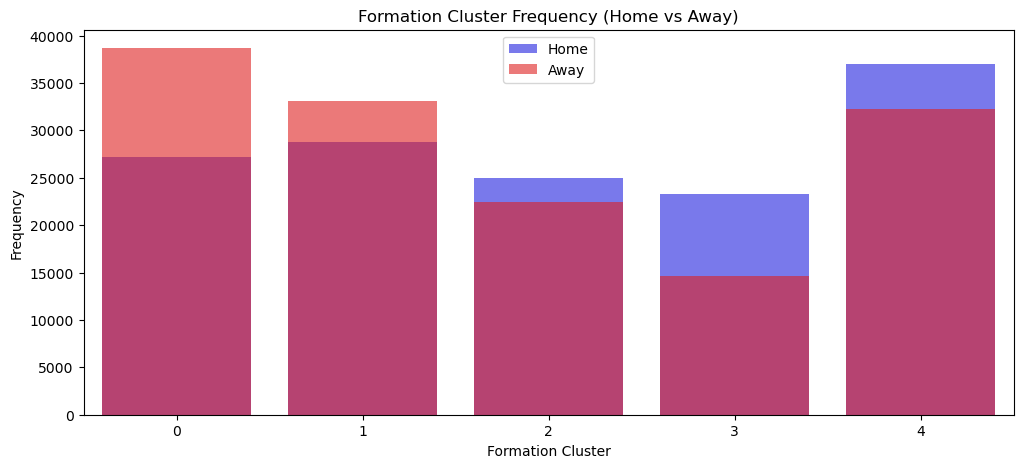

In [20]:
# Plot formation distributions
plt.figure(figsize=(12, 5))
sns.barplot(
    x=formation_counts_home.index,
    y=formation_counts_home.values,
    color="blue",
    alpha=0.6,
    label="Home",
)
sns.barplot(
    x=formation_counts_away.index,
    y=formation_counts_away.values,
    color="red",
    alpha=0.6,
    label="Away",
)
plt.xlabel("Formation Cluster")
plt.ylabel("Frequency")
plt.title("Formation Cluster Frequency (Home vs Away)")
plt.legend()
plt.show()


In [21]:
from scipy.spatial import Delaunay
import numpy as np


def plot_formation_for_cluster(tracking_data, cluster_id, title):
    """Plot player formation for a specific cluster using Delaunay triangulation"""
    cluster_data = tracking_data[tracking_data["formation_cluster"] == cluster_id]
    avg_positions = cluster_data.mean()  # Average positions

    # Extract only player positions
    x_coords = avg_positions[[col for col in avg_positions.index if "_x" in col]].values
    y_coords = avg_positions[[col for col in avg_positions.index if "_y" in col]].values

    # Perform Delaunay triangulation
    points = np.vstack((x_coords, y_coords)).T
    tri = Delaunay(points)

    plt.figure(figsize=(8, 6))
    plt.triplot(points[:, 0], points[:, 1], tri.simplices, color="gray", alpha=0.6)
    plt.scatter(points[:, 0], points[:, 1], c="red", s=100, label="Players")

    # Annotate players
    for i, txt in enumerate(avg_positions.index[::2]):
        plt.annotate(
            txt.split("_")[1], (points[i, 0], points[i, 1]), fontsize=10, ha="right"
        )

    plt.title(title)
    plt.xlabel("X Position (meters)")
    plt.ylabel("Y Position (meters)")
    plt.grid(True)
    plt.show()


Error plotting cluster 0: list index out of range
Error plotting cluster 1: list index out of range
Error plotting cluster 2: list index out of range


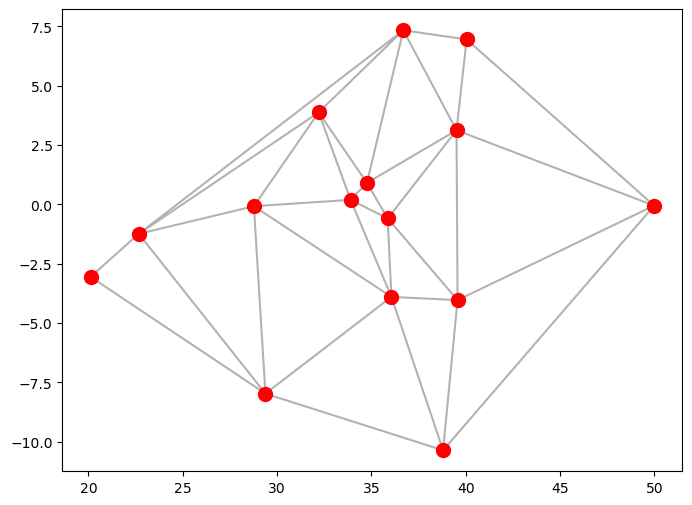

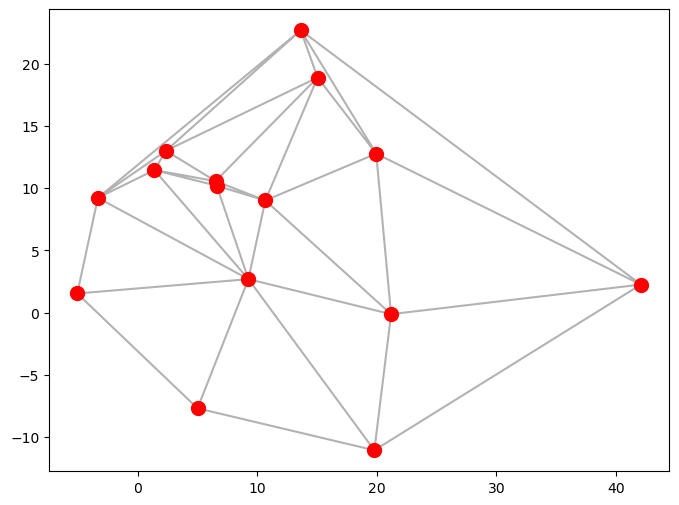

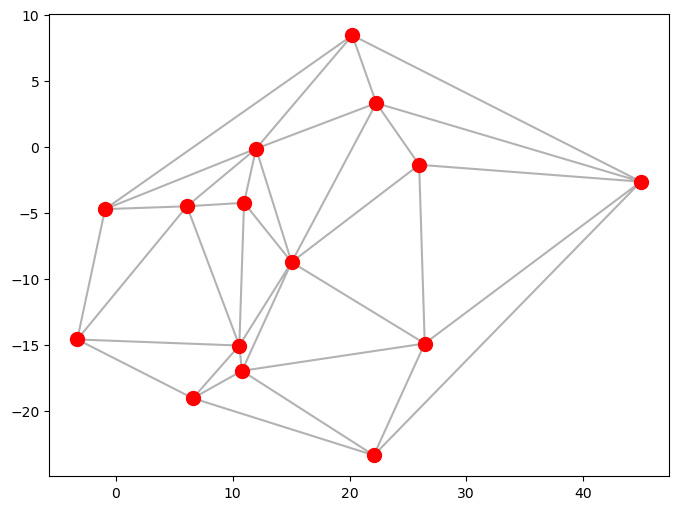

In [22]:
# Plot formations for first 3 clusters
for i in range(3):
    try:
        plot_formation_for_cluster(tracking_home, i, f"Home Formation Cluster {i}")
        plot_formation_for_cluster(tracking_away, i, f"Away Formation Cluster {i}")
    except IndexError as e:
        print(f"Error plotting cluster {i}: {e}")


In [23]:
import Metrica_Viz as mviz
from scipy.spatial import ConvexHull


In [56]:
# Function to calculate average player positions
def get_average_positions(positions):
    """
    Calculate the average position for each player.
    """
    # Take the mean of player positions (remove NaNs before taking the mean)
    avg_positions = np.nanmean(positions, axis=0)
    return avg_positions


In [57]:
# Function to plot team formation based on average positions
def plot_team_formation(avg_positions, team_name, color):
    """Plot the team formation for the given team using convex hulls."""

    # Extract player positions (x and y)
    x_coords = avg_positions[::2]  # Player X coordinates
    y_coords = avg_positions[1::2]  # Player Y coordinates

    # Ensure there are 11 players
    if len(x_coords) != 11:
        print(f"Skipping {team_name} formation (unexpected number of players).")
        return

    points = np.vstack((x_coords, y_coords)).T  # Stack as (x, y) coordinates

    # Create pitch plot using Metrica's function
    fig, ax = mviz.plot_pitch(field_color="white", field_dimen=(106.0, 68.0))

    # Draw convex hull to outline team shape
    hull = ConvexHull(points)
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], color=color, lw=2)

    # Plot player positions
    ax.scatter(
        points[:, 0], points[:, 1], c=color, s=100, label=team_name, edgecolors="black"
    )

    # Annotate jersey numbers
    for i in range(len(x_coords)):
        ax.annotate(
            f"Player {i + 1}", (x_coords[i], y_coords[i]), fontsize=10, ha="right"
        )

    # Set the title with proper formatting
    ax.set_title(f"{team_name} Formation (Average)", fontsize=16)
    ax.set_xlabel("X Position (meters)", fontsize=12)
    ax.set_ylabel("Y Position (meters)", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


In [59]:
# Perform clustering for home and away teams
home_clusters = kmeans_home.fit_predict(home_positions)
away_clusters = kmeans_away.fit_predict(away_positions)


In [61]:
# Get the average positions for the clusters (assign clusters after averaging)
home_avg_positions = np.array(
    [
        get_average_positions(home_positions[home_clusters == i])
        for i in range(n_clusters)
    ]
)
away_avg_positions = np.array(
    [
        get_average_positions(away_positions[away_clusters == i])
        for i in range(n_clusters)
    ]
)


Plotting Home Team Formation for Cluster 0


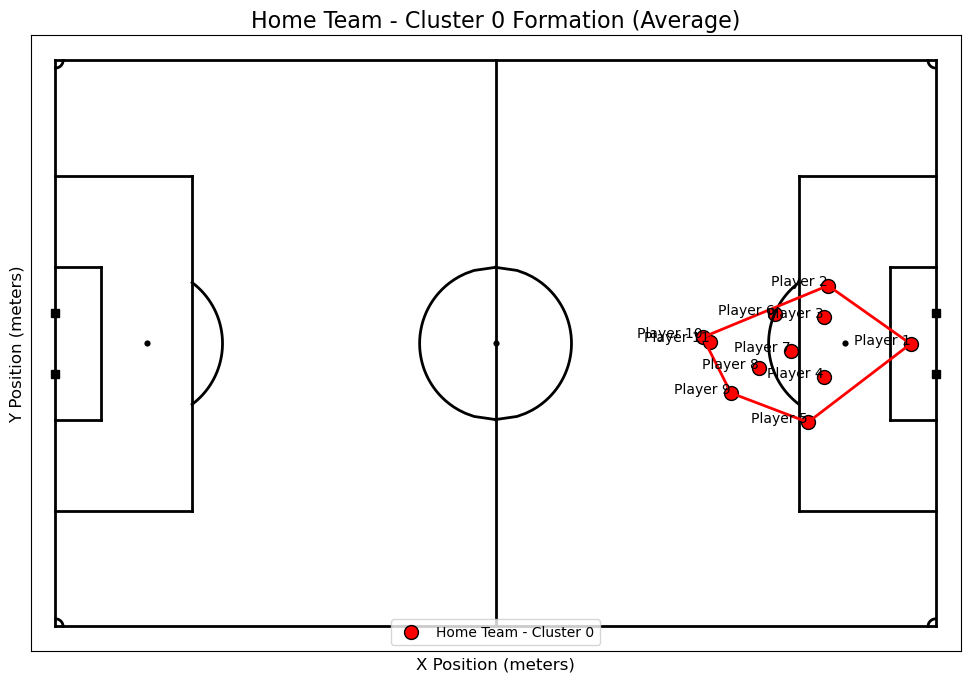

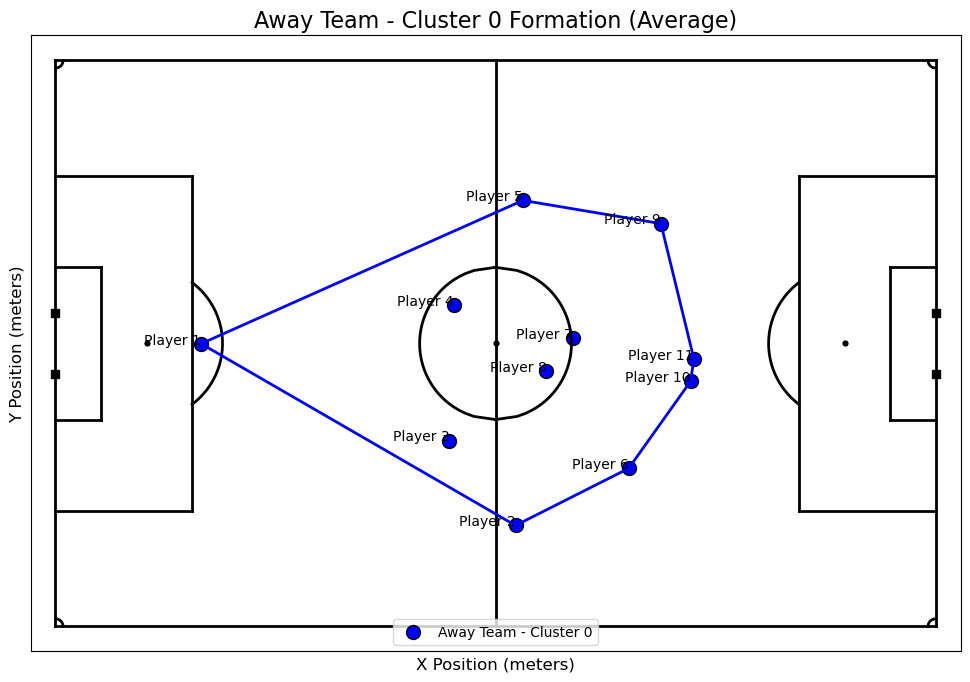

Plotting Home Team Formation for Cluster 1


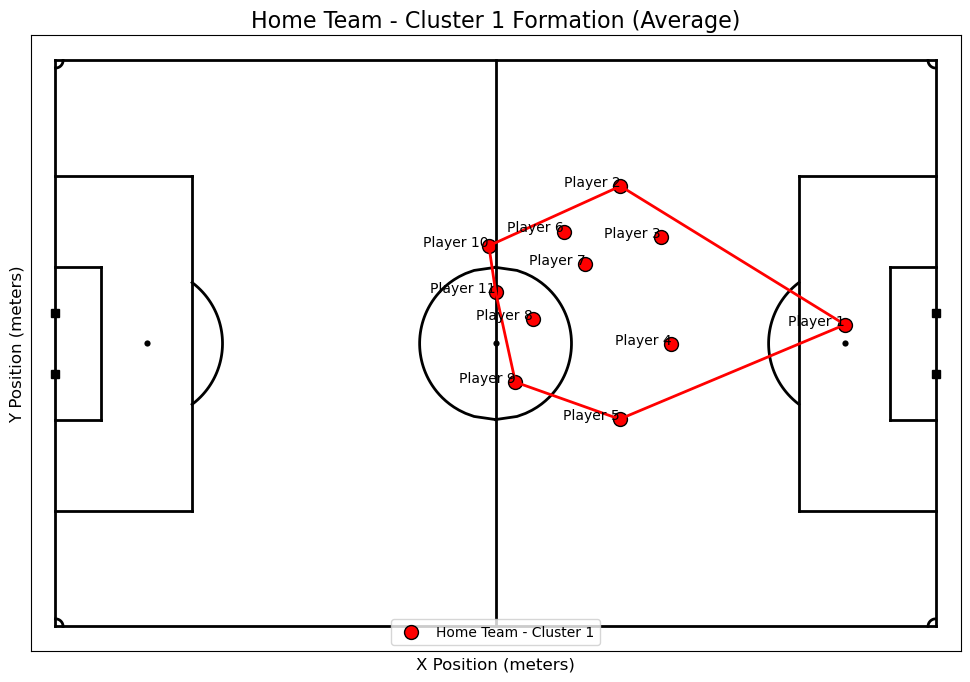

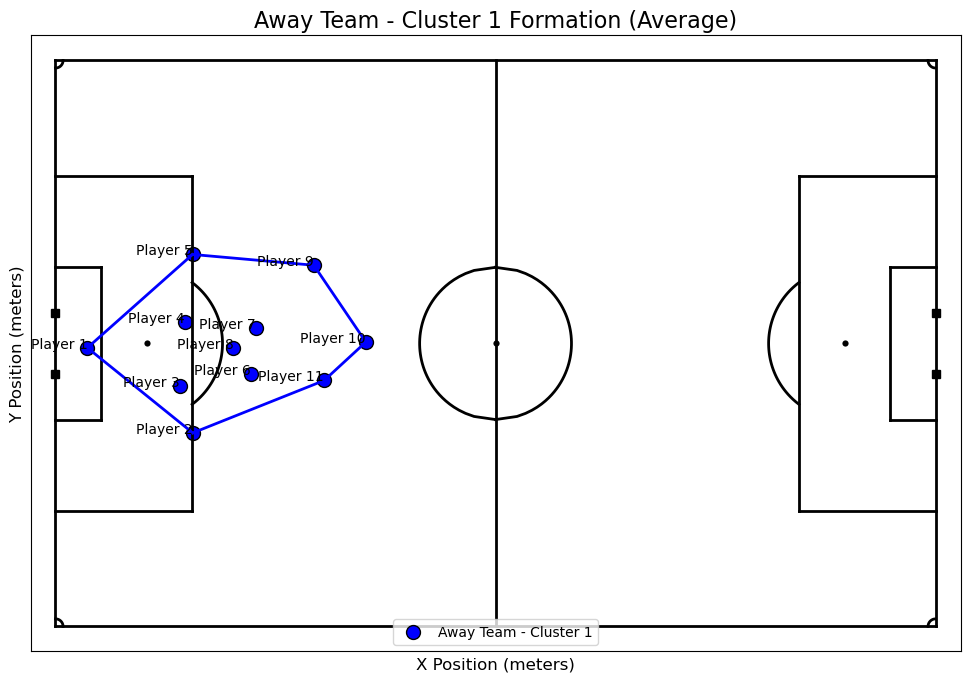

Plotting Home Team Formation for Cluster 2


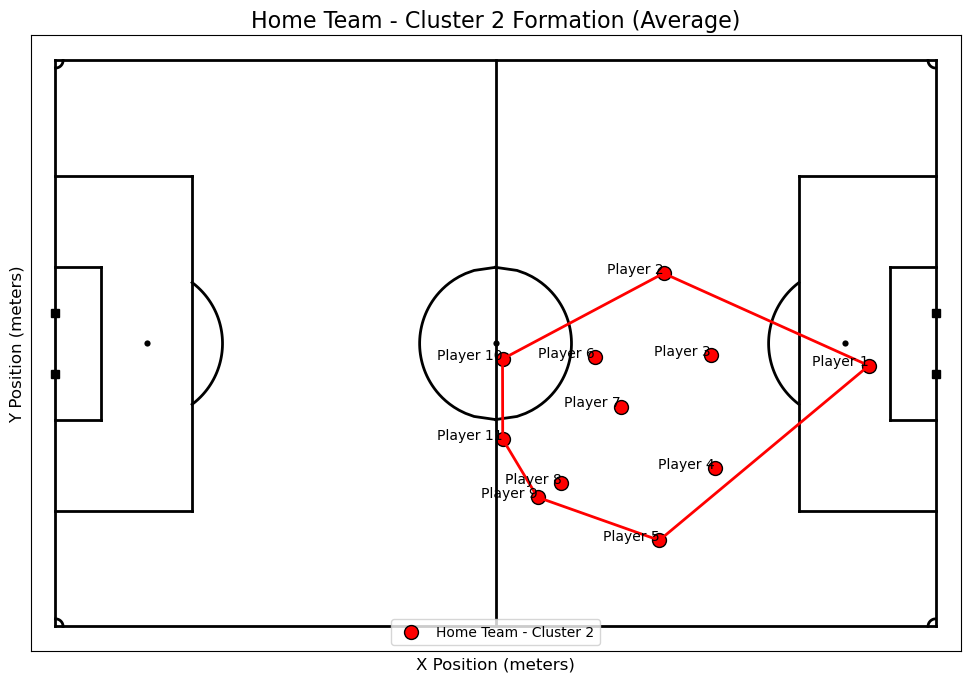

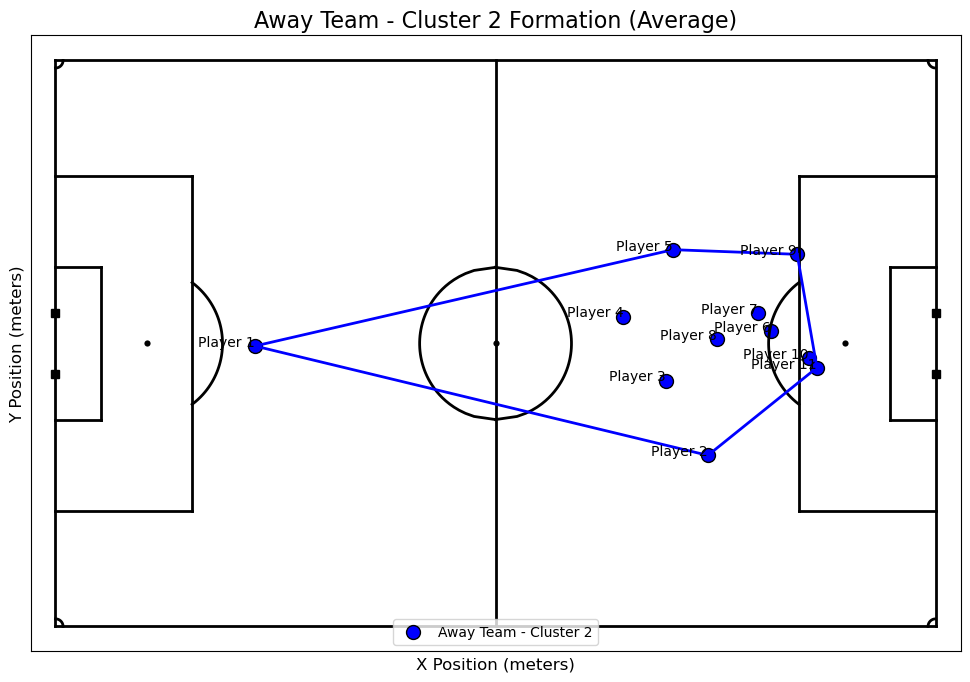

Plotting Home Team Formation for Cluster 3


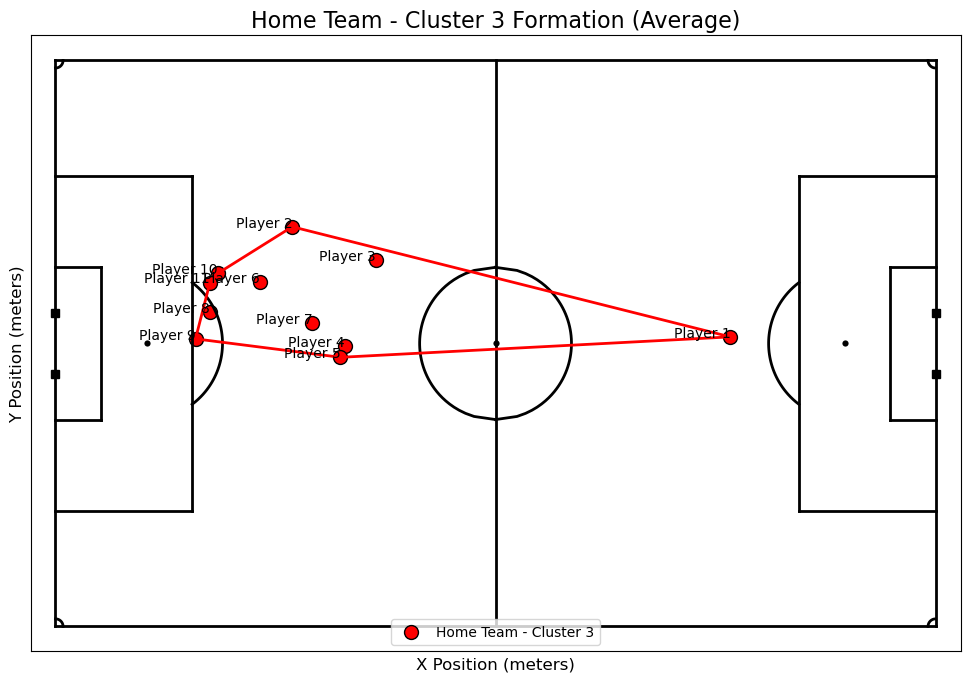

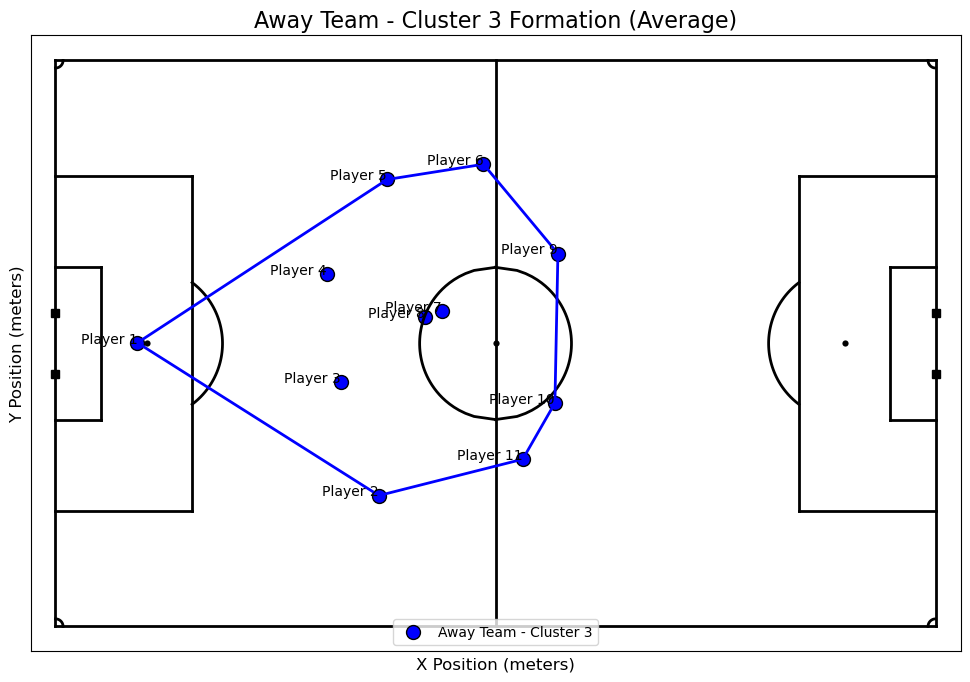

Plotting Home Team Formation for Cluster 4


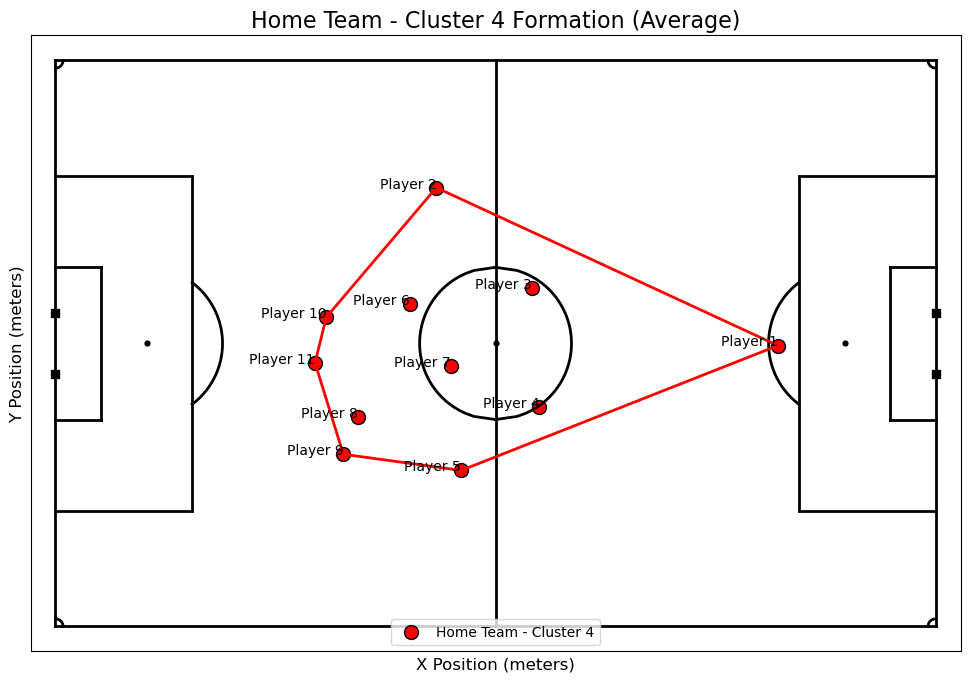

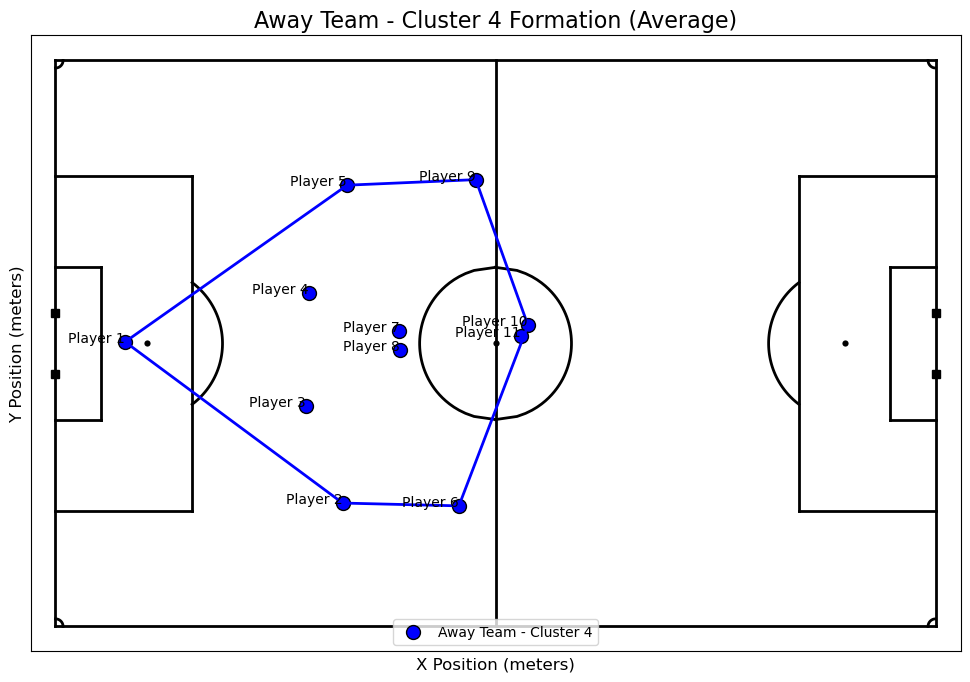

In [62]:
# Plot formations based on cluster labels (use the average position for each cluster)
for i in range(n_clusters):
    print(f"Plotting Home Team Formation for Cluster {i}")
    # Plot the team formations based on the average positions of the players
    plot_team_formation(home_avg_positions[i], f"Home Team - Cluster {i}", "red")
    plot_team_formation(away_avg_positions[i], f"Away Team - Cluster {i}", "blue")


In [63]:
# Helper function to associate events with formations
def associate_events_with_formation(events, tracking_data, cluster_labels, cluster_id):
    """
    Associates events with specific formations by matching the event frames with the formation cluster.
    """
    # Filter events that correspond to frames within the specific cluster
    cluster_frames = tracking_data[
        tracking_data["formation_cluster"] == cluster_id
    ].index

    # Filter events based on frame numbers
    events_in_cluster = events[events["Start Frame"].isin(cluster_frames)]

    return events_in_cluster


Home Team Formation 0 - Events:
      Team       Type              Subtype  Period  Start Frame  \
27    Home   RECOVERY         INTERCEPTION       1         1431   
28    Home       PASS                  NaN       1         1467   
29    Home       PASS                  NaN       1         1489   
30    Away  CHALLENGE          AERIAL-LOST       1         1576   
31    Home  CHALLENGE           AERIAL-WON       1         1578   
...    ...        ...                  ...     ...          ...   
1900  Away       PASS                  NaN       2       135929   
1901  Away       PASS                CROSS       2       136020   
1902  Away  CHALLENGE           AERIAL-WON       2       136060   
1903  Away       SHOT  HEAD-OFF TARGET-OUT       2       136060   
1904  Home  CHALLENGE          AERIAL-LOST       2       136060   

      Start Time [s]  End Frame  End Time [s]       From         To  Start X  \
27             57.24       1431         57.24    Player1        NaN     0.87   
28 

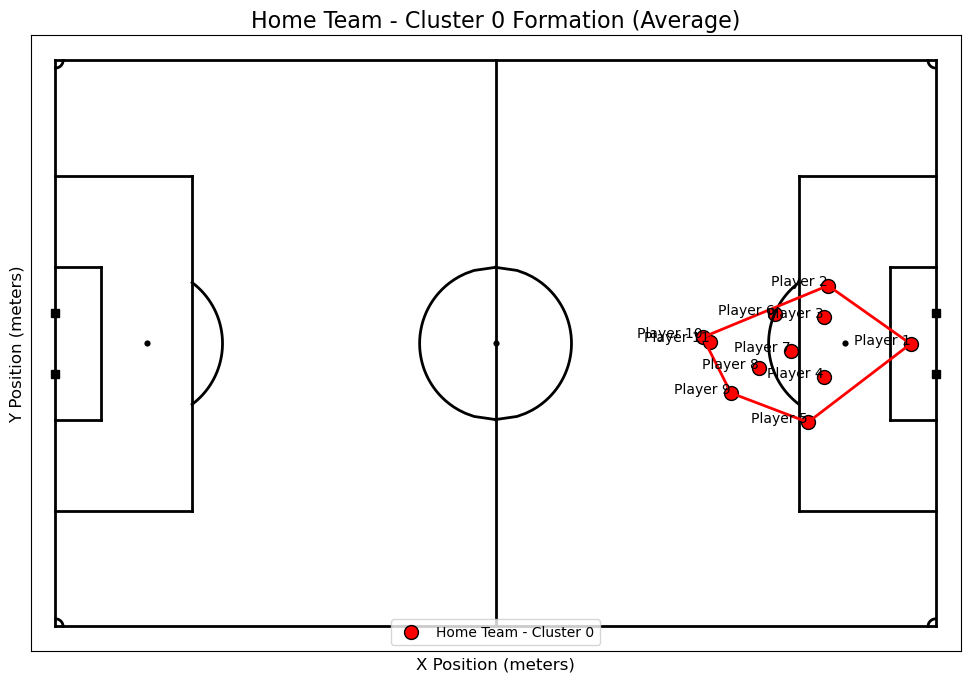

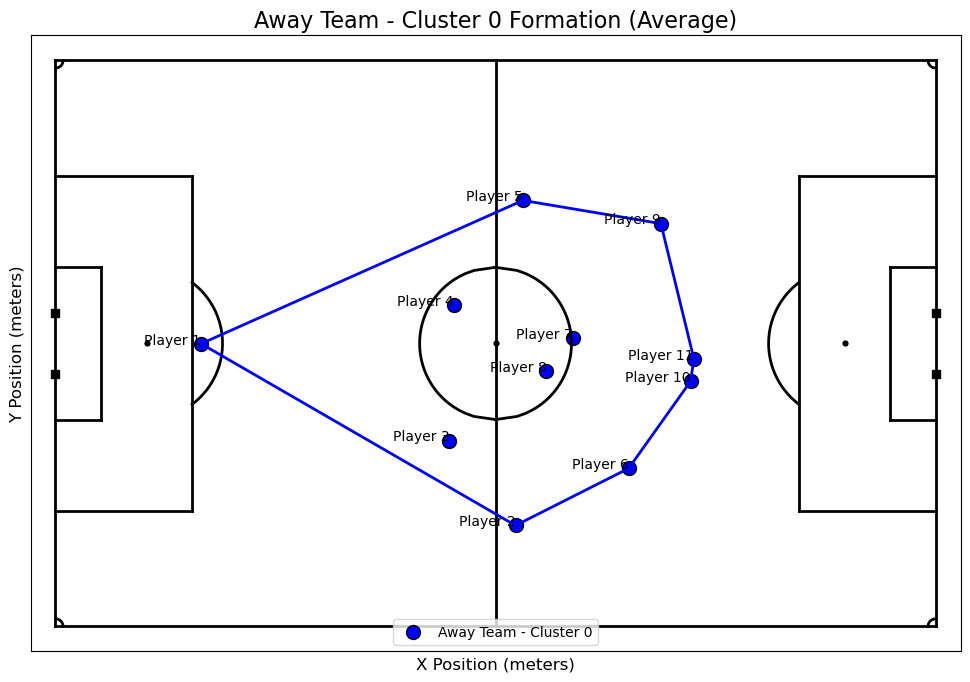

Home Team Formation 1 - Events:
      Team       Type       Subtype  Period  Start Frame  Start Time [s]  \
0     Away  SET PIECE      KICK OFF       1           51            2.04   
1     Away       PASS           NaN       1           51            2.04   
2     Away       PASS           NaN       1          146            5.84   
3     Away       PASS           NaN       1          248            9.92   
4     Away       PASS           NaN       1          316           12.64   
...    ...        ...           ...     ...          ...             ...   
1916  Home       PASS           NaN       2       137303         5492.12   
1930  Away  BALL LOST  INTERCEPTION       2       140122         5604.88   
1931  Home  CHALLENGE   AERIAL-LOST       2       140180         5607.20   
1932  Away  CHALLENGE   AERIAL-LOST       2       140183         5607.32   
1933  Home   RECOVERY           NaN       2       140211         5608.44   

      End Frame  End Time [s]      From        To  Star

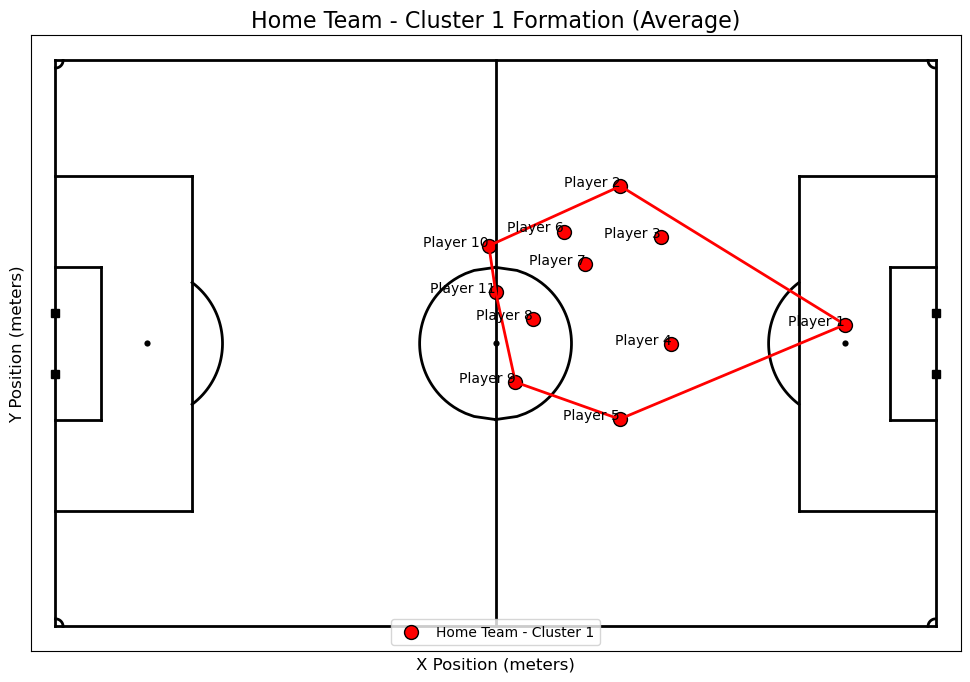

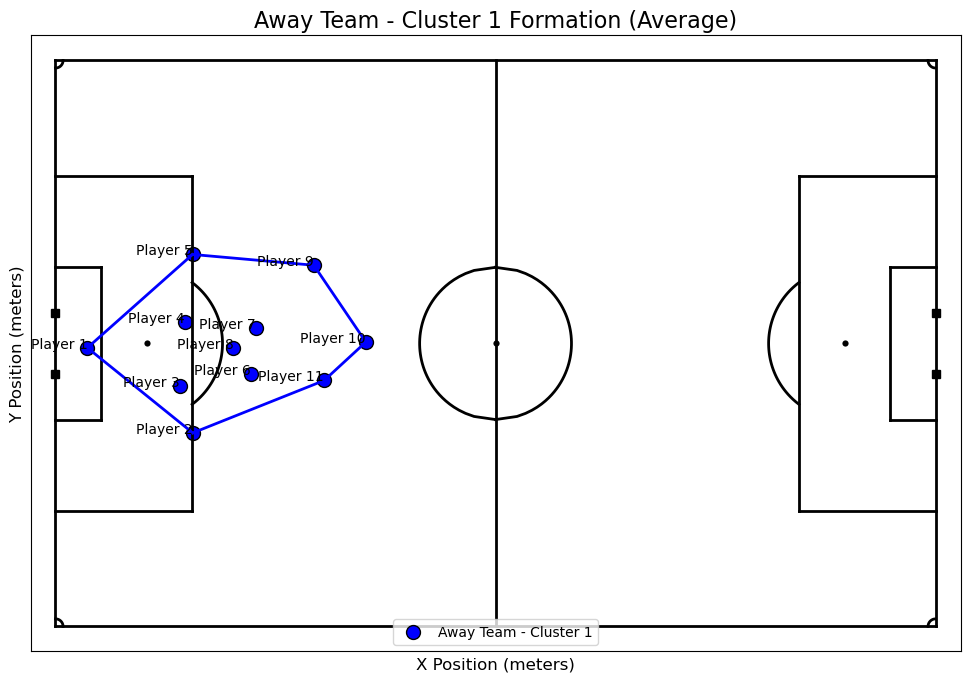

Home Team Formation 2 - Events:
      Team            Type            Subtype  Period  Start Frame  \
11    Away       SET PIECE           THROW IN       1          672   
12    Away            PASS                NaN       1          672   
13    Away            PASS                NaN       1          768   
41    Away       BALL LOST       INTERCEPTION       1         1843   
42    Home        RECOVERY       INTERCEPTION       1         1874   
...    ...             ...                ...     ...          ...   
1917  Home            PASS                NaN       2       137334   
1918  Away       CHALLENGE  GROUND-FAULT-LOST       2       137416   
1919  Home       CHALLENGE   GROUND-FAULT-WON       2       137429   
1920  Home  FAULT RECEIVED                NaN       2       137429   
1934  Home        BALL OUT          CLEARANCE       2       140265   

      Start Time [s]  End Frame  End Time [s]      From        To  Start X  \
11             26.88        672         26.88  Pl

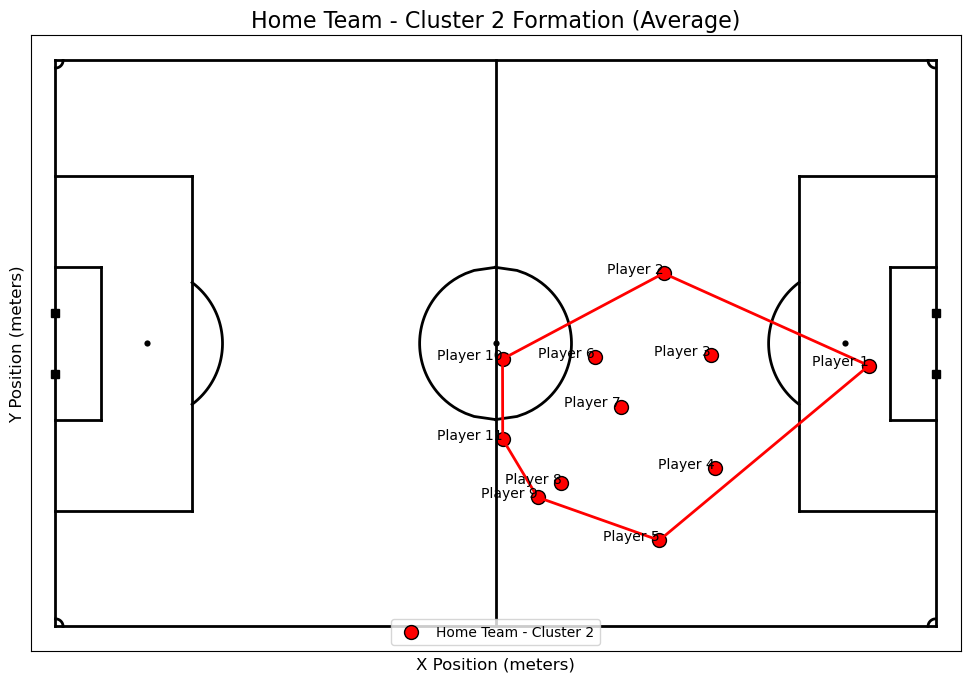

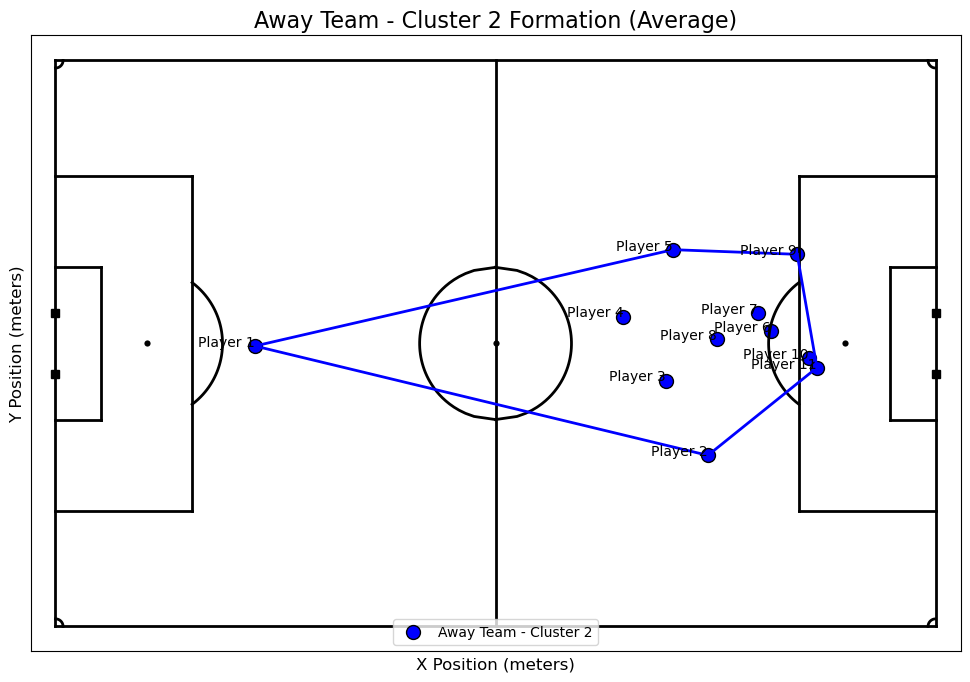

Home Team Formation 3 - Events:
      Team            Type           Subtype  Period  Start Frame  \
63    Away       BALL LOST               NaN       1         3131   
77    Home            PASS               NaN       1         4132   
78    Home            PASS               NaN       1         4223   
79    Home            PASS               NaN       1         4261   
80    Home            PASS               NaN       1         4291   
...    ...             ...               ...     ...          ...   
1826  Away       CHALLENGE  TACKLE-FAULT-WON       2       129922   
1827  Away  FAULT RECEIVED               NaN       2       129922   
1926  Home       SET PIECE         FREE KICK       2       139891   
1927  Home            SHOT   ON TARGET-SAVED       2       139891   
1928  Away        RECOVERY             SAVED       2       139926   

      Start Time [s]  End Frame  End Time [s]      From       To  Start X  \
63            125.24       3217        128.68  Player18      N

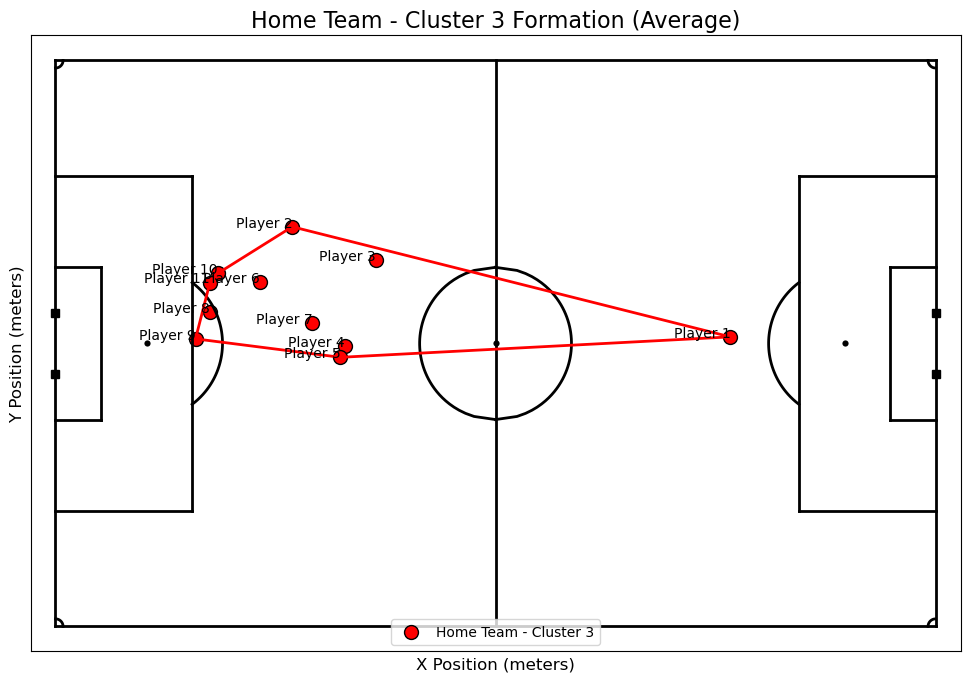

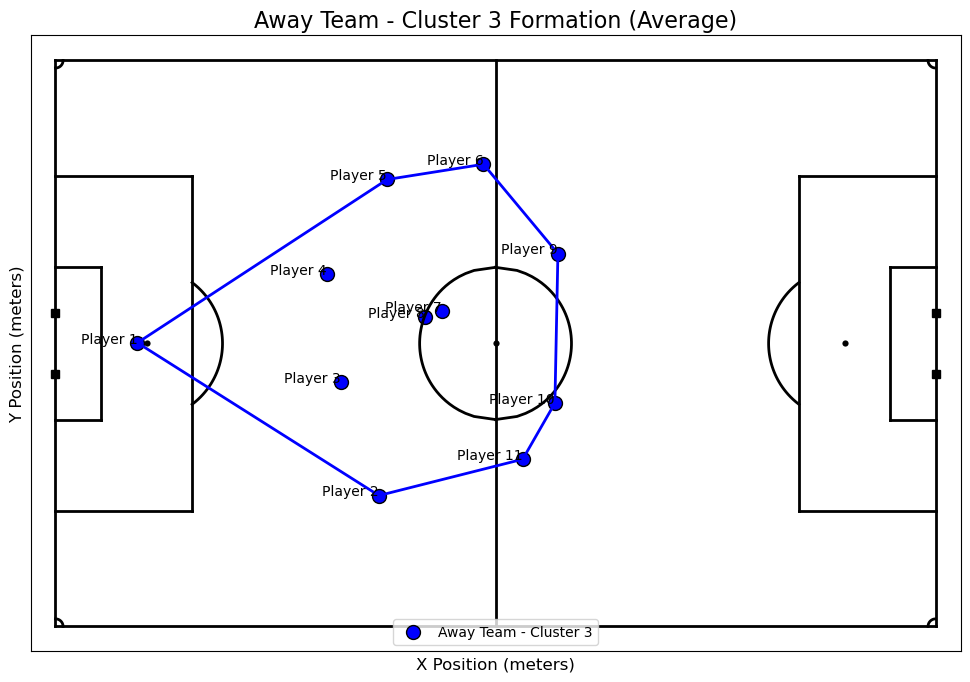

Home Team Formation 4 - Events:
      Team       Type            Subtype  Period  Start Frame  Start Time [s]  \
5     Away       PASS                NaN       1          395           15.80   
6     Away  BALL LOST       INTERCEPTION       1          451           18.04   
7     Away  CHALLENGE        GROUND-LOST       1          504           20.16   
8     Home  CHALLENGE         GROUND-WON       1          504           20.16   
9     Home   RECOVERY       INTERCEPTION       1          504           20.16   
...    ...        ...                ...     ...          ...             ...   
1922  Home  BALL LOST       INTERCEPTION       2       138250         5530.00   
1923  Away  CHALLENGE  AERIAL-FAULT-LOST       2       138327         5533.08   
1924  Home  CHALLENGE   AERIAL-FAULT-WON       2       138334         5533.36   
1925  Away       CARD             YELLOW       2       138445         5537.80   
1929  Away       PASS                NaN       2       140010         5600.40

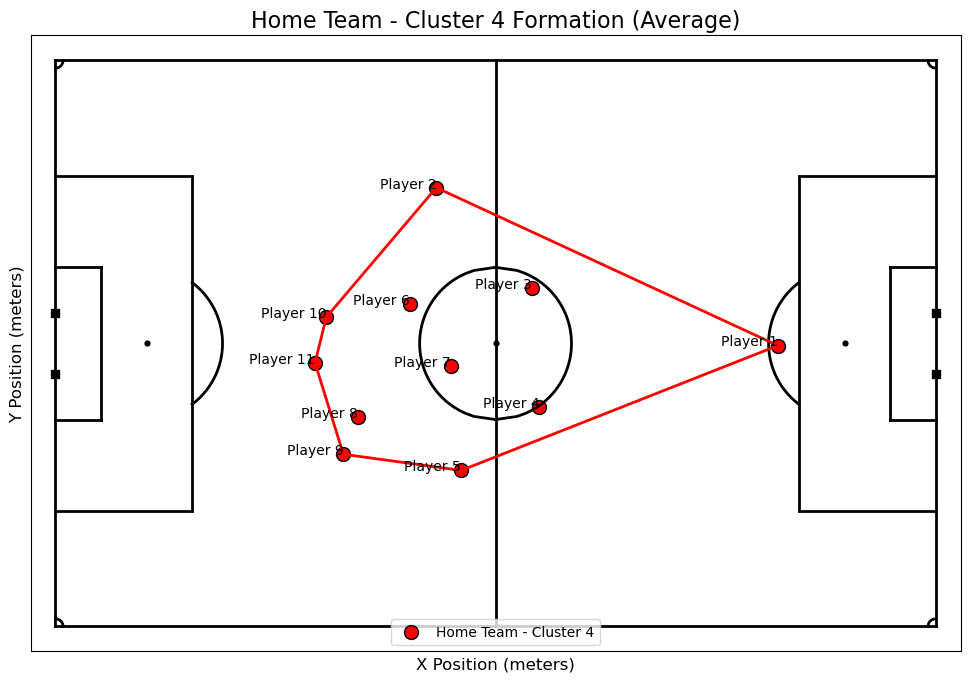

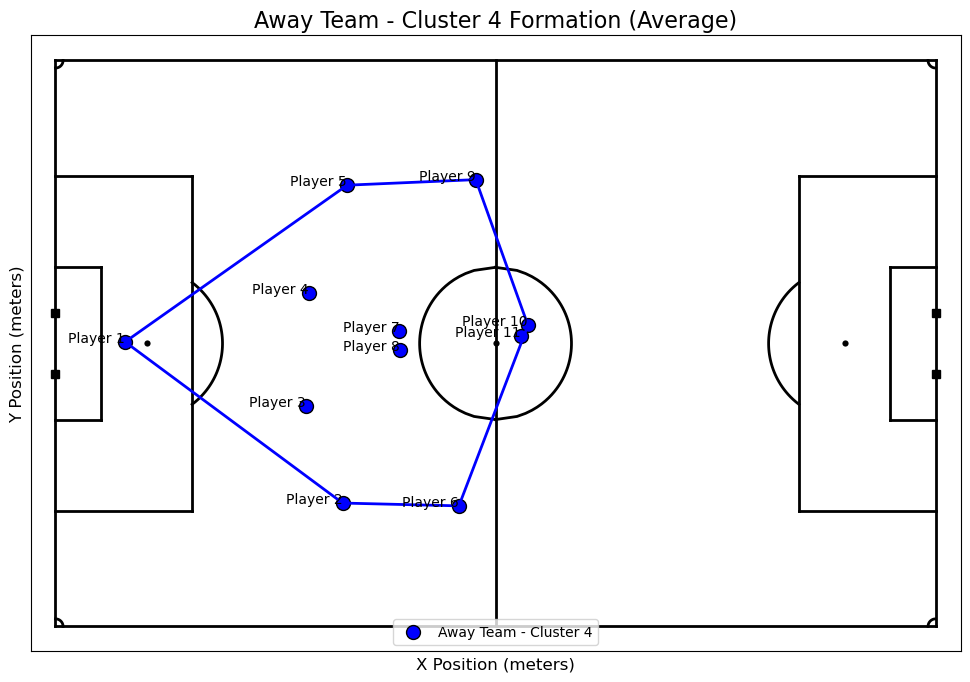

In [65]:
# Associate events with formations for each cluster
for i in range(n_clusters):
    # Get events for this cluster
    home_events_in_cluster = associate_events_with_formation(
        events, tracking_home, home_clusters, i
    )
    away_events_in_cluster = associate_events_with_formation(
        events, tracking_away, away_clusters, i
    )

    # Print out the events happening during this formation
    print(f"Home Team Formation {i} - Events:")
    print(home_events_in_cluster)

    print(f"Away Team Formation {i} - Events:")
    print(away_events_in_cluster)

    # Plot the formations for Home and Away teams in this cluster
    plot_team_formation(home_avg_positions[i], f"Home Team - Cluster {i}", "red")
    plot_team_formation(away_avg_positions[i], f"Away Team - Cluster {i}", "blue")


In [66]:
import Metrica_PitchControl as mpc
import Metrica_EPV as mepv


In [71]:
# Function to determine offensive or defensive nature of the formation
def classify_formation(avg_positions, home_team=True):
    """Classify formation as attacking, neutral, or defensive based on average player positions."""
    x_coords = avg_positions[::2]
    y_coords = avg_positions[1::2]

    if home_team:
        x_coords = [-x for x in x_coords]

    # Calculate the average x-coordinate (forward/backward position of the team)
    avg_x = np.mean(x_coords)

    # If more than half of the players are in the attacking half, classify as attacking
    if avg_x > 0:
        return "Attacking"
    elif avg_x < 0:
        return "Defensive"
    else:
        return "Neutral"


In [72]:
# Function to analyze events in each formation
def analyze_events_in_formation(events, cluster_id, tracking_data, formation_name):
    """Analyze the events during a specific formation cluster."""

    # Find frames corresponding to the given cluster
    cluster_frames = tracking_data[
        tracking_data["formation_cluster"] == cluster_id
    ].index
    events_in_formation = events[events["Start Frame"].isin(cluster_frames)]

    print(f"Events during {formation_name} Formation (Cluster {cluster_id}):")
    print(events_in_formation[["Type", "Subtype", "Start Time [s]", "Team"]])


In [73]:
# Map clusters to offensive/defensive categories
formation_labels = []
for i in range(n_clusters):
    home_class = classify_formation(home_avg_positions[i])
    away_class = classify_formation(away_avg_positions[i], home_team=False)
    formation_labels.append((home_class, away_class))


In [74]:
# Print out formation categories
for i, (home_class, away_class) in enumerate(formation_labels):
    print(f"Cluster {i} - Home Team: {home_class}, Away Team: {away_class}")


Cluster 0 - Home Team: Defensive, Away Team: Attacking
Cluster 1 - Home Team: Defensive, Away Team: Defensive
Cluster 2 - Home Team: Defensive, Away Team: Attacking
Cluster 3 - Home Team: Attacking, Away Team: Defensive
Cluster 4 - Home Team: Attacking, Away Team: Defensive


In [75]:
events

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,51,2.04,51,2.04,Player23,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,51,2.04,87,3.48,Player23,Player20,0.50,0.50,0.40,0.51
2,Away,PASS,NaN,1,146,5.84,186,7.44,Player20,Player18,0.43,0.50,0.44,0.22
3,Away,PASS,NaN,1,248,9.92,283,11.32,Player18,Player17,0.47,0.19,0.31,0.28
4,Away,PASS,NaN,1,316,12.64,346,13.84,Player17,Player16,0.29,0.32,0.26,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,Away,BALL LOST,INTERCEPTION,2,140122,5604.88,140183,5607.32,Player21,NaN,-0.54,-0.77,-0.29,-0.24
1931,Home,CHALLENGE,AERIAL-LOST,2,140180,5607.20,140180,5607.20,Player1,NaN,-0.31,-0.30,NaN,NaN
1932,Away,CHALLENGE,AERIAL-LOST,2,140183,5607.32,140183,5607.32,Player24,NaN,-0.32,-0.30,NaN,NaN
1933,Home,RECOVERY,NaN,2,140211,5608.44,140211,5608.44,Player12,NaN,-0.34,-0.32,NaN,NaN


Events during Home Team - Cluster 0 Formation (Cluster 0):
           Type              Subtype  Start Time [s]  Team
27     RECOVERY         INTERCEPTION           57.24  Home
28         PASS                  NaN           58.68  Home
29         PASS                  NaN           59.56  Home
30    CHALLENGE          AERIAL-LOST           63.04  Away
31    CHALLENGE           AERIAL-WON           63.12  Home
...         ...                  ...             ...   ...
1900       PASS                  NaN         5437.16  Away
1901       PASS                CROSS         5440.80  Away
1902  CHALLENGE           AERIAL-WON         5442.40  Away
1903       SHOT  HEAD-OFF TARGET-OUT         5442.40  Away
1904  CHALLENGE          AERIAL-LOST         5442.40  Home

[343 rows x 4 columns]
Events during Away Team - Cluster 0 Formation (Cluster 0):
                Type            Subtype  Start Time [s]  Team
11         SET PIECE           THROW IN           26.88  Away
12              PASS      

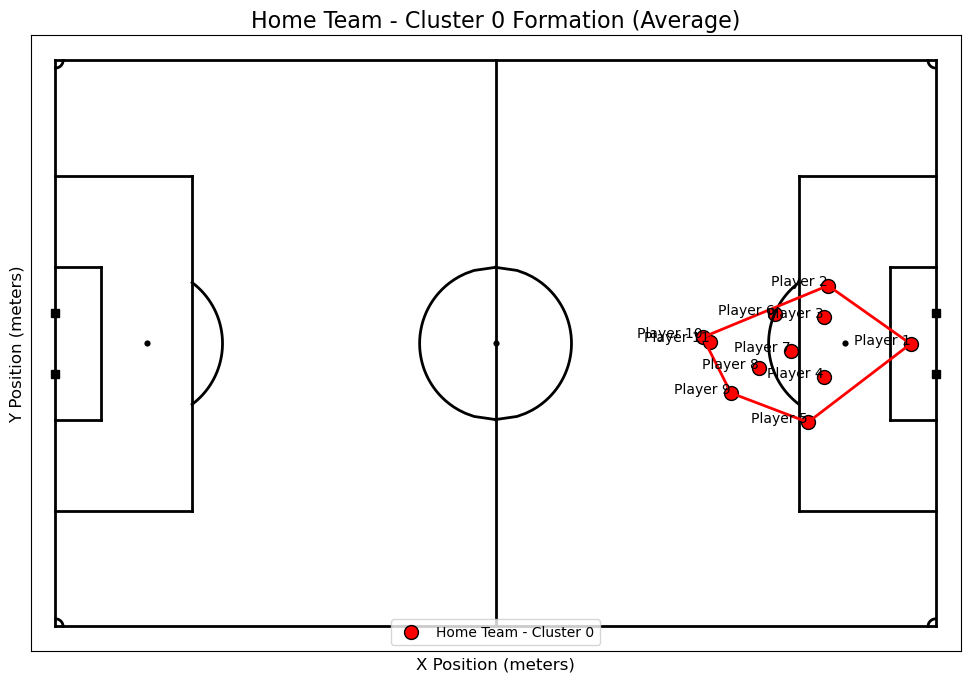

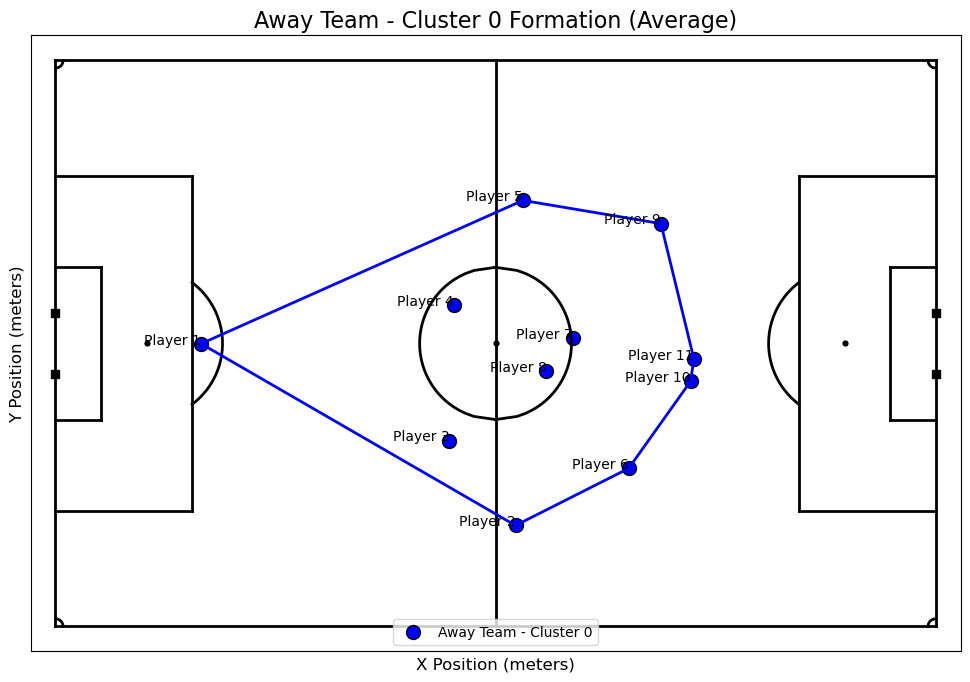

Events during Home Team - Cluster 1 Formation (Cluster 1):
           Type       Subtype  Start Time [s]  Team
0     SET PIECE      KICK OFF            2.04  Away
1          PASS           NaN            2.04  Away
2          PASS           NaN            5.84  Away
3          PASS           NaN            9.92  Away
4          PASS           NaN           12.64  Away
...         ...           ...             ...   ...
1916       PASS           NaN         5492.12  Home
1930  BALL LOST  INTERCEPTION         5604.88  Away
1931  CHALLENGE   AERIAL-LOST         5607.20  Home
1932  CHALLENGE   AERIAL-LOST         5607.32  Away
1933   RECOVERY           NaN         5608.44  Home

[401 rows x 4 columns]
Events during Away Team - Cluster 1 Formation (Cluster 1):
           Type          Subtype  Start Time [s]  Team
61     RECOVERY     INTERCEPTION          121.40  Away
62         PASS              NaN          122.76  Away
63    BALL LOST              NaN          125.24  Away
73         PAS

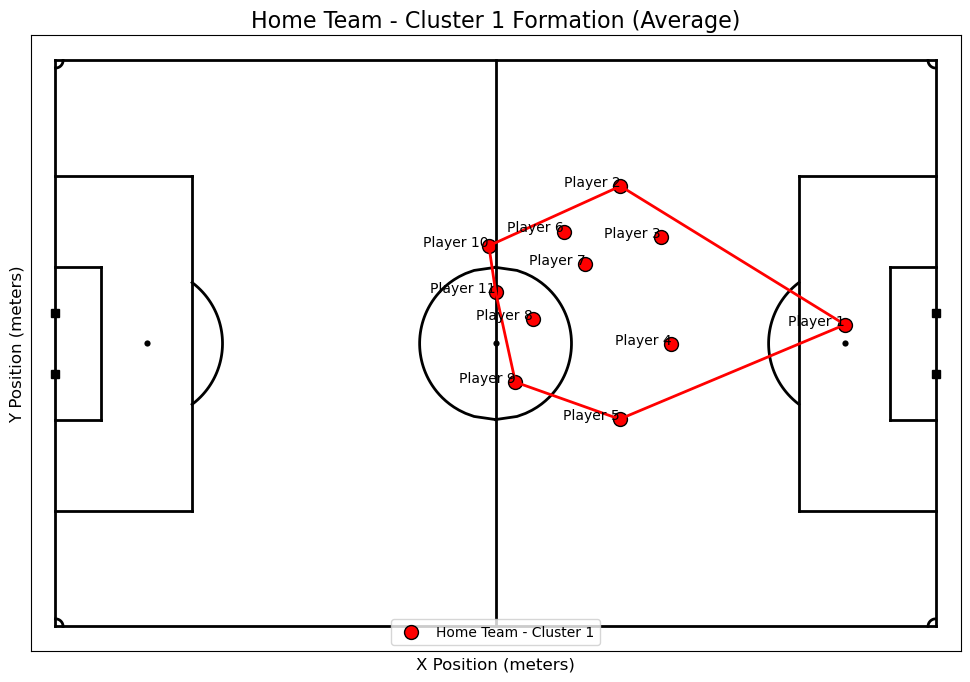

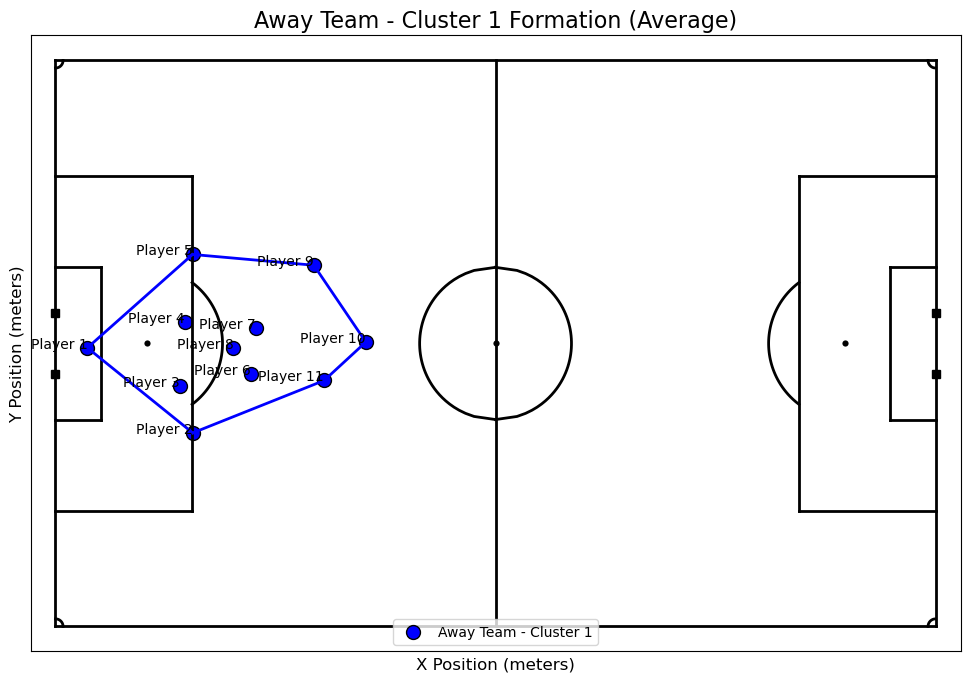

Events during Home Team - Cluster 2 Formation (Cluster 2):
                Type            Subtype  Start Time [s]  Team
11         SET PIECE           THROW IN           26.88  Away
12              PASS                NaN           26.88  Away
13              PASS                NaN           30.72  Away
41         BALL LOST       INTERCEPTION           73.72  Away
42          RECOVERY       INTERCEPTION           74.96  Home
...              ...                ...             ...   ...
1917            PASS                NaN         5493.36  Home
1918       CHALLENGE  GROUND-FAULT-LOST         5496.64  Away
1919       CHALLENGE   GROUND-FAULT-WON         5497.16  Home
1920  FAULT RECEIVED                NaN         5497.16  Home
1934        BALL OUT          CLEARANCE         5610.60  Home

[393 rows x 4 columns]
Events during Away Team - Cluster 2 Formation (Cluster 2):
           Type              Subtype  Start Time [s]  Team
28         PASS                  NaN           58.68  H

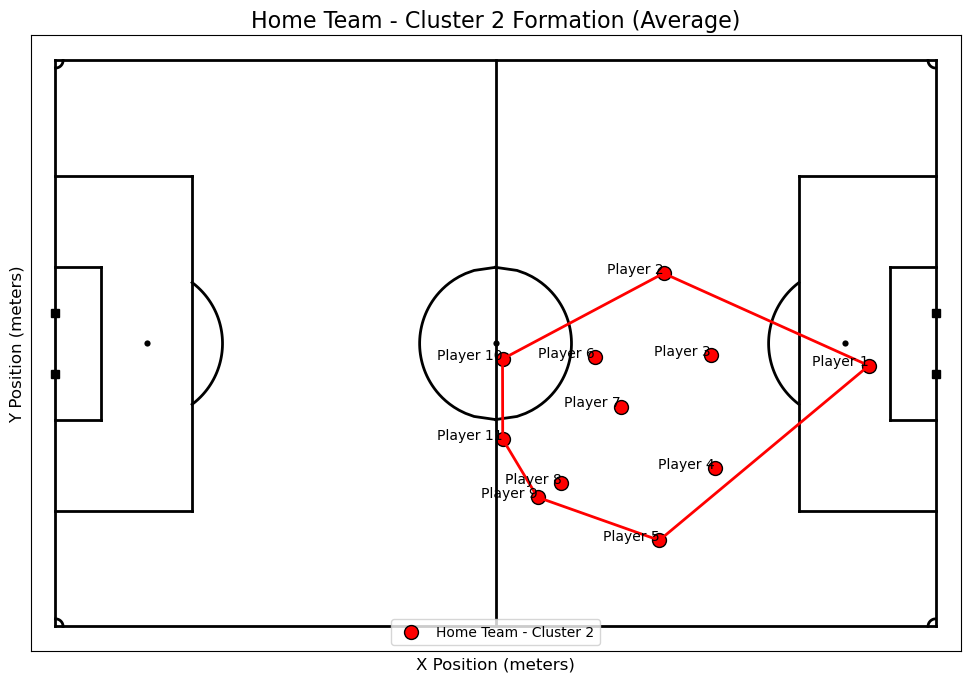

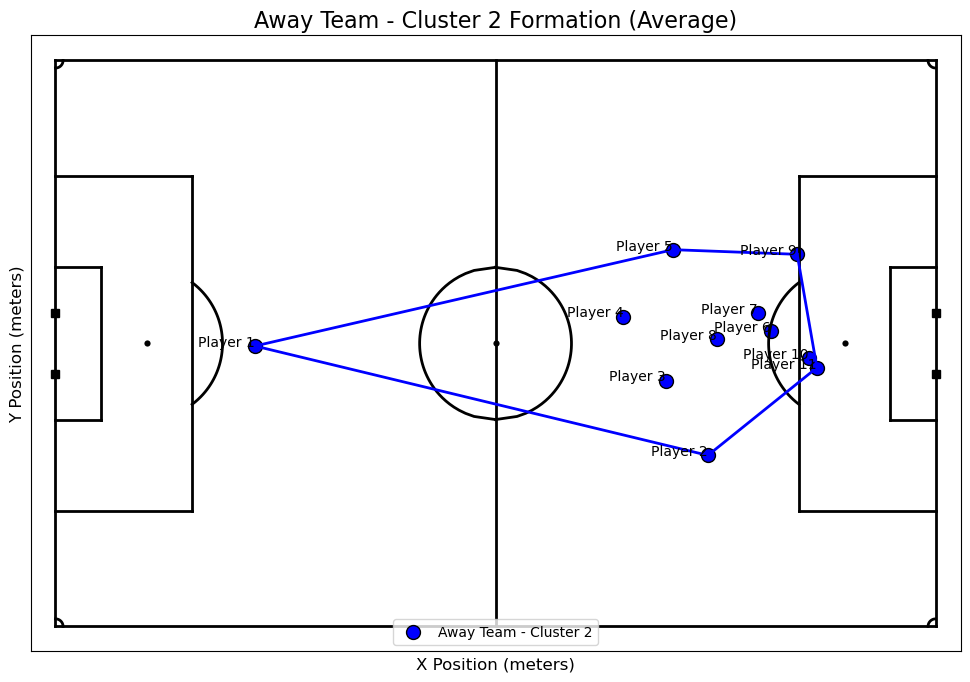

Events during Home Team - Cluster 3 Formation (Cluster 3):
                Type           Subtype  Start Time [s]  Team
63         BALL LOST               NaN          125.24  Away
77              PASS               NaN          165.28  Home
78              PASS               NaN          168.92  Home
79              PASS               NaN          170.44  Home
80              PASS               NaN          171.64  Home
...              ...               ...             ...   ...
1826       CHALLENGE  TACKLE-FAULT-WON         5196.88  Away
1827  FAULT RECEIVED               NaN         5196.88  Away
1926       SET PIECE         FREE KICK         5595.64  Home
1927            SHOT   ON TARGET-SAVED         5595.64  Home
1928        RECOVERY             SAVED         5597.04  Away

[262 rows x 4 columns]
Events during Away Team - Cluster 3 Formation (Cluster 3):
           Type       Subtype  Start Time [s]  Team
1256       PASS           NaN         3352.88  Away
1437  CHALLENGE    GRO

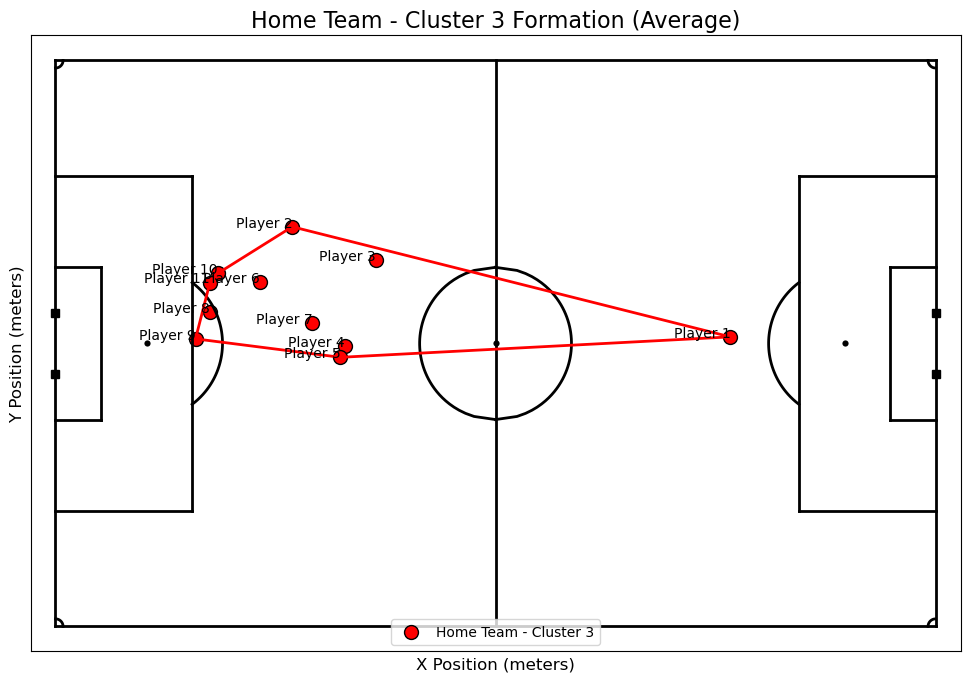

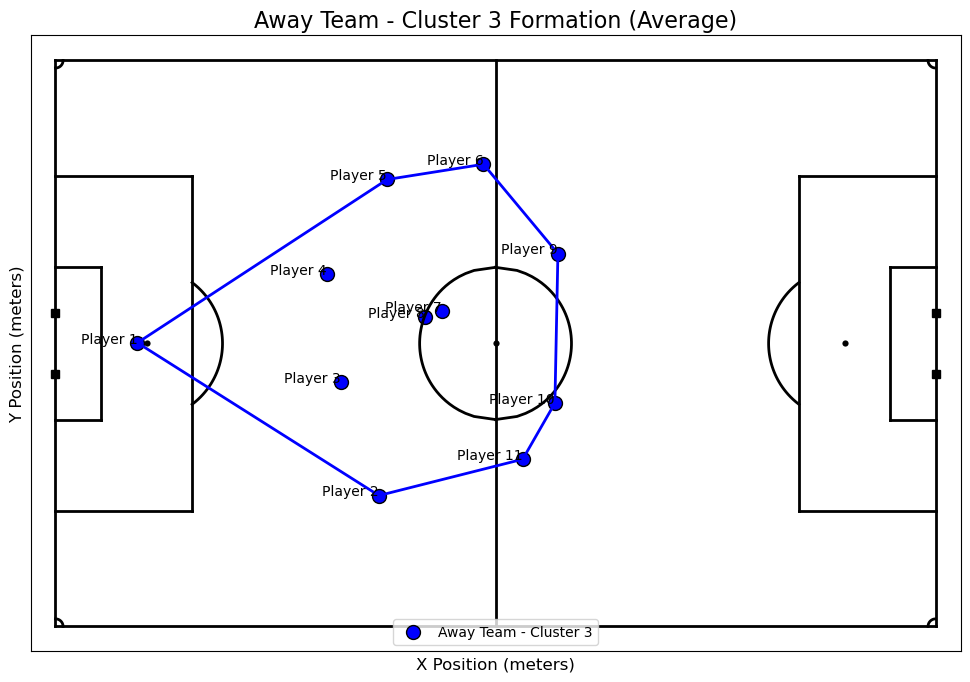

Events during Home Team - Cluster 4 Formation (Cluster 4):
           Type            Subtype  Start Time [s]  Team
5          PASS                NaN           15.80  Away
6     BALL LOST       INTERCEPTION           18.04  Away
7     CHALLENGE        GROUND-LOST           20.16  Away
8     CHALLENGE         GROUND-WON           20.16  Home
9      RECOVERY       INTERCEPTION           20.16  Home
...         ...                ...             ...   ...
1922  BALL LOST       INTERCEPTION         5530.00  Home
1923  CHALLENGE  AERIAL-FAULT-LOST         5533.08  Away
1924  CHALLENGE   AERIAL-FAULT-WON         5533.36  Home
1925       CARD             YELLOW         5537.80  Away
1929       PASS                NaN         5600.40  Away

[536 rows x 4 columns]
Events during Away Team - Cluster 4 Formation (Cluster 4):
           Type            Subtype  Start Time [s]  Team
0     SET PIECE           KICK OFF            2.04  Away
1          PASS                NaN            2.04  Away
2  

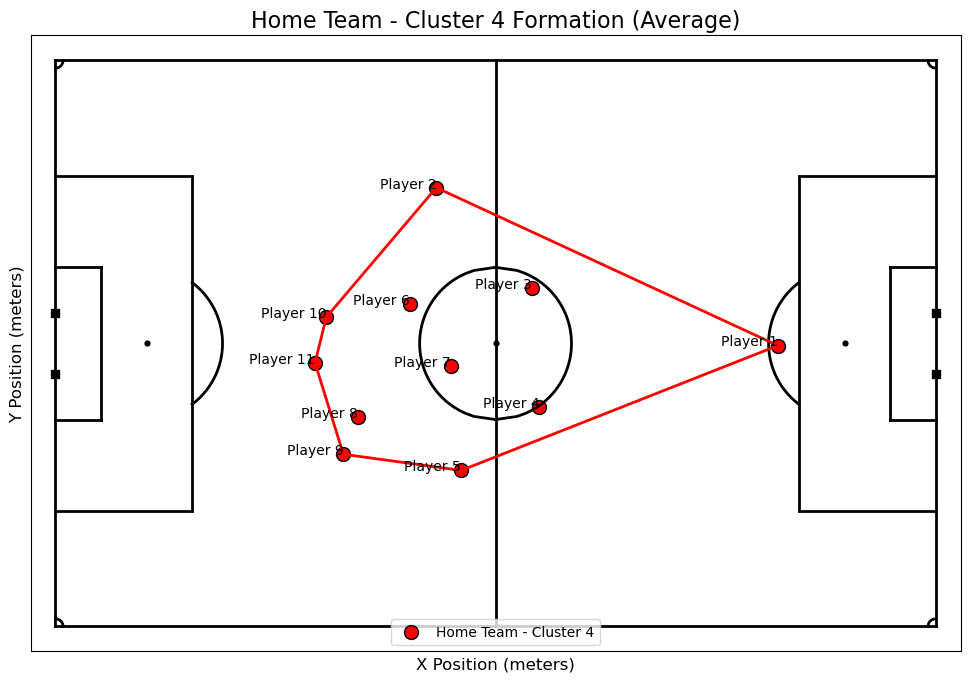

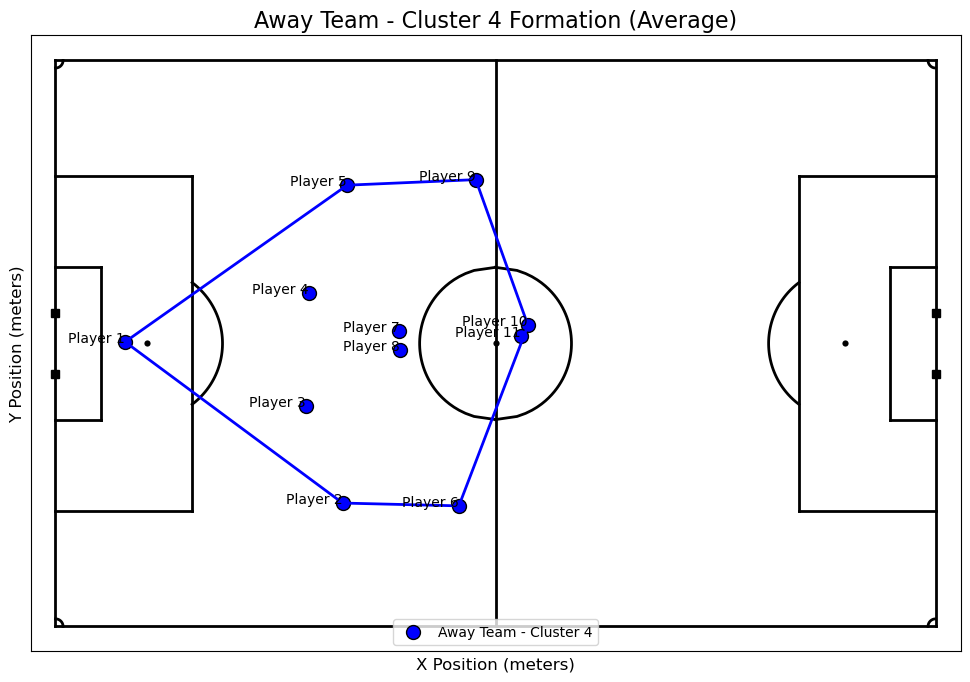

In [76]:
# Now, analyze events based on formations
for i in range(n_clusters):
    # Get events associated with this formation (home and away)
    analyze_events_in_formation(events, i, tracking_home, f"Home Team - Cluster {i}")
    analyze_events_in_formation(events, i, tracking_away, f"Away Team - Cluster {i}")

    # Plot the formations for Home and Away teams in this cluster
    plot_team_formation(home_avg_positions[i], f"Home Team - Cluster {i}", "red")
    plot_team_formation(away_avg_positions[i], f"Away Team - Cluster {i}", "blue")


In [78]:
# Find goalkeeper numbers for both teams
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]
print(f"Home Goalkeeper: Player {GK_numbers[0]}")
print(f"Away Goalkeeper: Player {GK_numbers[1]}")


Goalkeeper identified: Player 11 (Column: Home_11_x)
Goalkeeper identified: Player 25 (Column: Away_25_x)
Home Goalkeeper: Player 11
Away Goalkeeper: Player 25


In [79]:
# EPV analysis for a specific event
event_number = 1753  # Example: home team assist to header off target
EEPV_added, EPV_diff = mepv.calculate_epv_added(
    event_number, events, tracking_home, tracking_away, GK_numbers, EPV, params
)
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(106.0, 68.0),
    n_grid_cells_x=50,
    offsides=True,
)


NameError: name 'EPV' is not defined

In [58]:
# def plot_team_formation(tracking_data, cluster_id, team_name, color):
#     """Plot the team formation for a specific cluster using convex hulls."""

#     # Find the goalkeeper number using Metrica's function
#     gk_number = mio.find_goalkeeper(tracking_data)

#     # Filter data for the given formation cluster
#     cluster_data = tracking_data[tracking_data["formation_cluster"] == cluster_id]

#     print(f"Cluster data shape for cluster {cluster_id}: {cluster_data.shape}")
#     if cluster_data.empty:
#         print(f"Skipping {team_name} formation {cluster_id} (no data).")
#         return

#     # Extract player position columns (ignoring ball_x, ball_y, and other non-player columns)
#     player_columns = [col for col in cluster_data.columns if "_x" in col or "_y" in col]
#     print(f"Player columns: {player_columns}")

#     # Calculate the average positions manually (since mean() might cause issues with Series indexing)
#     x_coords = []
#     y_coords = []
#     player_numbers = []

#     for col in player_columns:
#         if "_x" in col:  # It's a player position column
#             try:
#                 player_number = int(col.split("_")[1])  # Extract player number
#                 corresponding_y = col.replace("_x", "_y")

#                 # Check if the corresponding y column exists and ensure positions are not NaN
#                 if corresponding_y in cluster_data.columns:
#                     # Get the x and y positions for the player in the current cluster (frame)
#                     x_pos = cluster_data[col].dropna().mean()
#                     y_pos = cluster_data[corresponding_y].dropna().mean()

#                     # Only include active players (those with valid positions)
#                     if not np.isnan(x_pos) and not np.isnan(y_pos):
#                         print(
#                             f"Processing player {player_number} - X: {x_pos}, Y: {y_pos}"
#                         )
#                         x_coords.append(x_pos)
#                         y_coords.append(y_pos)
#                         player_numbers.append(player_number)
#             except ValueError:
#                 # Skip columns where player number extraction fails (e.g., `ball_x`, `ball_y`)
#                 continue

#     print(f"x_coords: {x_coords}")
#     print(f"y_coords: {y_coords}")
#     print(f"player_numbers: {player_numbers}")

#     # Ensure all 11 players are plotted (starting 11 + substitutes on the field)
#     if len(x_coords) < 11:
#         print(f"Skipping {team_name} formation {cluster_id} (not enough players).")
#         return

#     points = np.vstack((x_coords, y_coords)).T  # Stack as (x, y) coordinates

#     # Create pitch plot using Metrica's function
#     fig, ax = mviz.plot_pitch(field_color="white", field_dimen=(106.0, 68.0))

#     # Draw convex hull to outline team shape
#     hull = ConvexHull(points)
#     for simplex in hull.simplices:
#         ax.plot(points[simplex, 0], points[simplex, 1], color=color, lw=2)

#     # Plot player positions
#     ax.scatter(
#         points[:, 0], points[:, 1], c=color, s=100, label=team_name, edgecolors="black"
#     )

#     # Annotate jersey numbers
#     for i, txt in enumerate(player_numbers):
#         ax.annotate(txt, (points[i, 0], points[i, 1]), fontsize=10, ha="right")

#     # Set the title with proper formatting
#     ax.set_title(f"{team_name} Formation - Cluster {cluster_id}", fontsize=16)
#     ax.set_xlabel("X Position (meters)", fontsize=12)
#     ax.set_ylabel("Y Position (meters)", fontsize=12)
#     plt.legend()
#     plt.grid(True)
#     plt.show()


Goalkeeper identified: Player 11 (Column: Home_11_x)
Cluster data shape for cluster 0: (27150, 33)
Player columns: ['Home_11_x', 'Home_11_y', 'Home_1_x', 'Home_1_y', 'Home_2_x', 'Home_2_y', 'Home_3_x', 'Home_3_y', 'Home_4_x', 'Home_4_y', 'Home_5_x', 'Home_5_y', 'Home_6_x', 'Home_6_y', 'Home_7_x', 'Home_7_y', 'Home_8_x', 'Home_8_y', 'Home_9_x', 'Home_9_y', 'Home_10_x', 'Home_10_y', 'Home_12_x', 'Home_12_y', 'Home_13_x', 'Home_13_y', 'Home_14_x', 'Home_14_y', 'ball_x', 'ball_y']
Processing player 11 - X: 49.98577849502762, Y: -0.04947141510128919
Processing player 1 - X: 40.04566812302026, Y: 6.952695114548803
Processing player 2 - X: 39.50974766187845, Y: 3.125843285451197
Processing player 3 - X: 39.56476248176796, Y: -4.030185078453038
Processing player 4 - X: 38.7971422401506, Y: -10.3575609009009
Processing player 5 - X: 34.76196170902394, Y: 0.9074024942909757
Processing player 6 - X: 33.89454547624309, Y: 0.19461016427256
Processing player 7 - X: 36.05936567292817, Y: -3.894134886

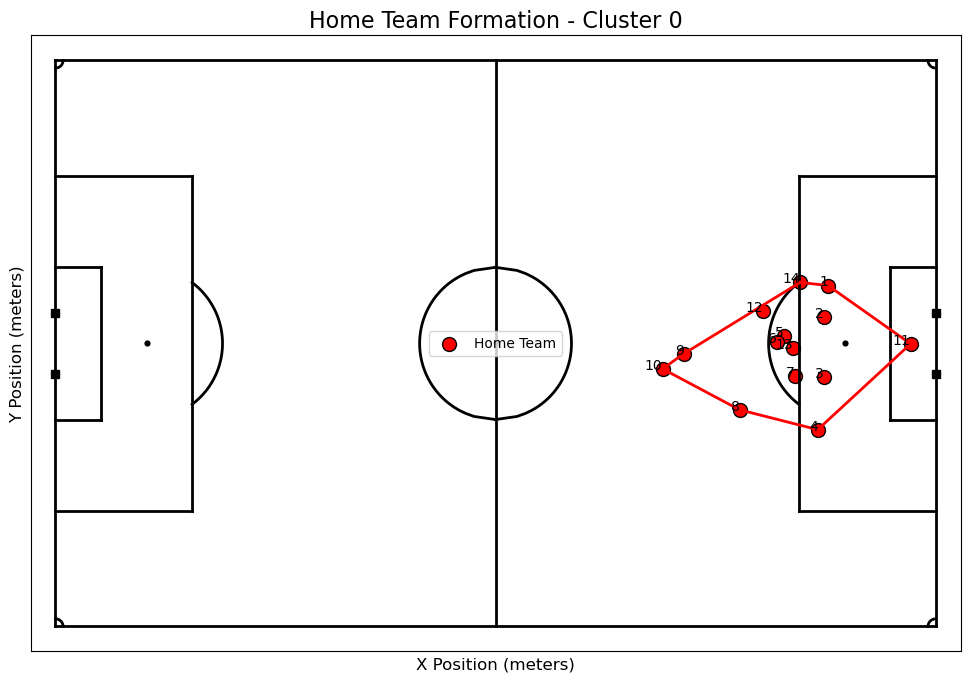

Goalkeeper identified: Player 25 (Column: Away_25_x)
Cluster data shape for cluster 0: (38679, 29)
Player columns: ['Away_25_x', 'Away_25_y', 'Away_15_x', 'Away_15_y', 'Away_16_x', 'Away_16_y', 'Away_17_x', 'Away_17_y', 'Away_18_x', 'Away_18_y', 'Away_19_x', 'Away_19_y', 'Away_20_x', 'Away_20_y', 'Away_21_x', 'Away_21_y', 'Away_22_x', 'Away_22_y', 'Away_23_x', 'Away_23_y', 'Away_24_x', 'Away_24_y', 'Away_26_x', 'Away_26_y', 'ball_x', 'ball_y']
Processing player 25 - X: -35.46520479846945, Y: -0.030582138111119775
Processing player 15 - X: 2.404044866723545, Y: -21.866661900255952
Processing player 16 - X: -5.568778526332118, Y: -11.667742966467593
Processing player 17 - X: -4.990226612890716, Y: 4.603705800046536
Processing player 18 - X: 3.295004395666899, Y: 17.182749503348067
Processing player 19 - X: 16.029579525840898, Y: -15.006429993536546
Processing player 20 - X: 9.283342262209466, Y: 0.6255814348871481
Processing player 21 - X: 6.1136870115566575, Y: -3.367533010677629
Proces

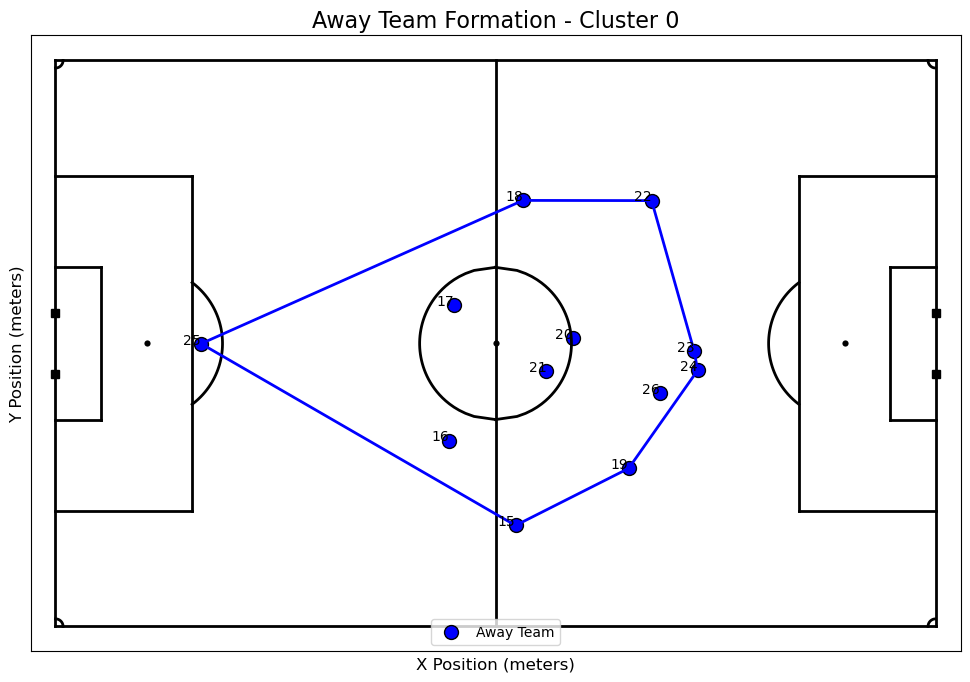

Goalkeeper identified: Player 11 (Column: Home_11_x)
Cluster data shape for cluster 1: (28790, 33)
Player columns: ['Home_11_x', 'Home_11_y', 'Home_1_x', 'Home_1_y', 'Home_2_x', 'Home_2_y', 'Home_3_x', 'Home_3_y', 'Home_4_x', 'Home_4_y', 'Home_5_x', 'Home_5_y', 'Home_6_x', 'Home_6_y', 'Home_7_x', 'Home_7_y', 'Home_8_x', 'Home_8_y', 'Home_9_x', 'Home_9_y', 'Home_10_x', 'Home_10_y', 'Home_12_x', 'Home_12_y', 'Home_13_x', 'Home_13_y', 'Home_14_x', 'Home_14_y', 'ball_x', 'ball_y']
Processing player 11 - X: 42.082524109065645, Y: 2.2600758707884685
Processing player 1 - X: 15.040523428968392, Y: 18.901281535255297
Processing player 2 - X: 19.943417348384855, Y: 12.782600484890587
Processing player 3 - X: 21.18794088919764, Y: -0.11937162625911776
Processing player 4 - X: 19.788875479303396, Y: -11.05749475892719
Processing player 5 - X: 6.505777908301493, Y: 10.57290427648489
Processing player 6 - X: 10.671858979506773, Y: 9.018833386592567
Processing player 7 - X: 9.254284566168808, Y: 2.6

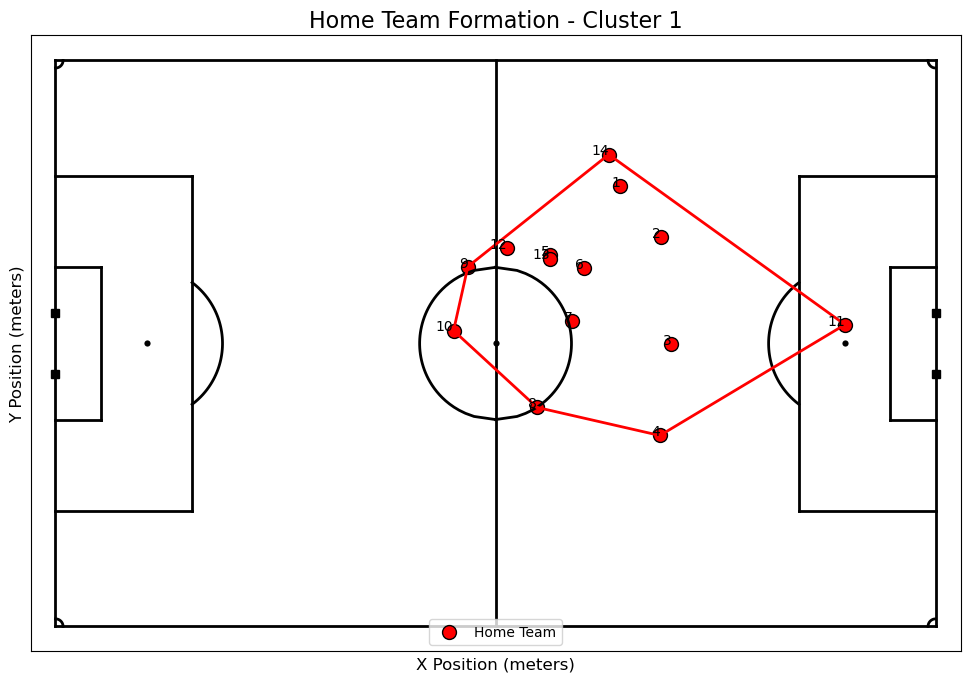

Goalkeeper identified: Player 25 (Column: Away_25_x)
Cluster data shape for cluster 1: (33112, 29)
Player columns: ['Away_25_x', 'Away_25_y', 'Away_15_x', 'Away_15_y', 'Away_16_x', 'Away_16_y', 'Away_17_x', 'Away_17_y', 'Away_18_x', 'Away_18_y', 'Away_19_x', 'Away_19_y', 'Away_20_x', 'Away_20_y', 'Away_21_x', 'Away_21_y', 'Away_22_x', 'Away_22_y', 'Away_23_x', 'Away_23_y', 'Away_24_x', 'Away_24_y', 'Away_26_x', 'Away_26_y', 'ball_x', 'ball_y']
Processing player 25 - X: -49.15711664955302, Y: -0.5232661814447934
Processing player 15 - X: -36.46643436337279, Y: -10.745208133607152
Processing player 16 - X: -37.9754396647741, Y: -5.06799379318676
Processing player 17 - X: -37.426792314568736, Y: 2.5161654409277605
Processing player 18 - X: -36.489894994563905, Y: 10.690633574534914
Processing player 19 - X: -29.4716383238705, Y: -3.664171600628171
Processing player 20 - X: -28.866756200169124, Y: 1.8555372263831837
Processing player 21 - X: -31.580990112949987, Y: -0.5094114894902152
Proc

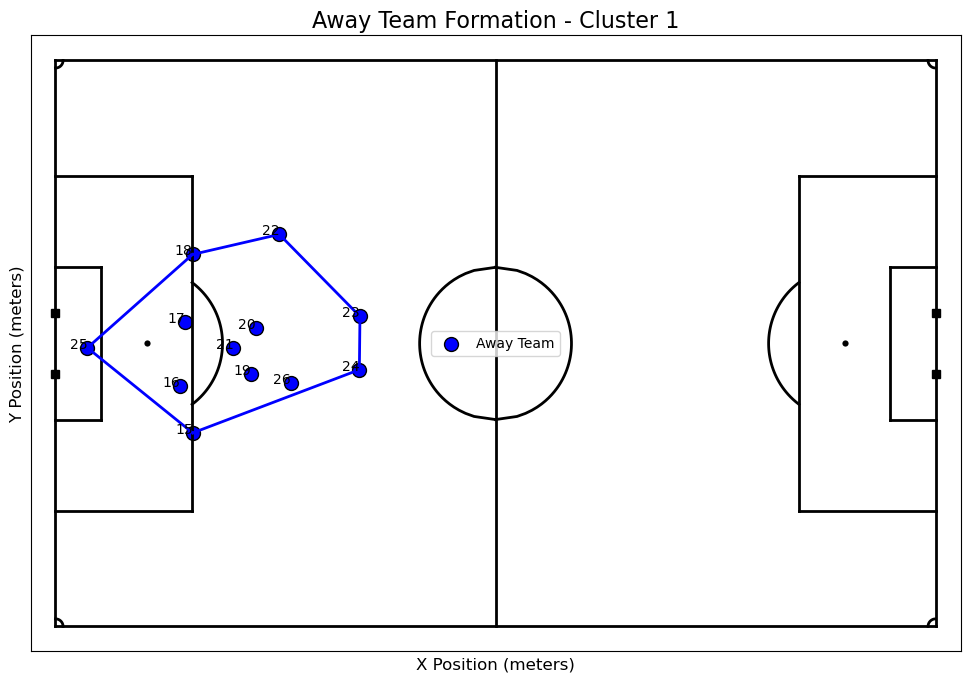

Goalkeeper identified: Player 11 (Column: Home_11_x)
Cluster data shape for cluster 2: (24958, 33)
Player columns: ['Home_11_x', 'Home_11_y', 'Home_1_x', 'Home_1_y', 'Home_2_x', 'Home_2_y', 'Home_3_x', 'Home_3_y', 'Home_4_x', 'Home_4_y', 'Home_5_x', 'Home_5_y', 'Home_6_x', 'Home_6_y', 'Home_7_x', 'Home_7_y', 'Home_8_x', 'Home_8_y', 'Home_9_x', 'Home_9_y', 'Home_10_x', 'Home_10_y', 'Home_12_x', 'Home_12_y', 'Home_13_x', 'Home_13_y', 'Home_14_x', 'Home_14_y', 'ball_x', 'ball_y']
Processing player 11 - X: 44.954895218366865, Y: -2.662272419264364
Processing player 1 - X: 20.24064572161231, Y: 8.427104670246013
Processing player 2 - X: 25.963212568314766, Y: -1.3828890103373666
Processing player 3 - X: 26.440796889173814, Y: -14.921203245452359
Processing player 4 - X: 22.076696946904846, Y: -23.38816489286951
Processing player 5 - X: 10.965635188717046, Y: -4.2633881913614875
Processing player 6 - X: 15.039856378716244, Y: -8.76124821860726
Processing player 7 - X: 10.560034033175738, Y: 

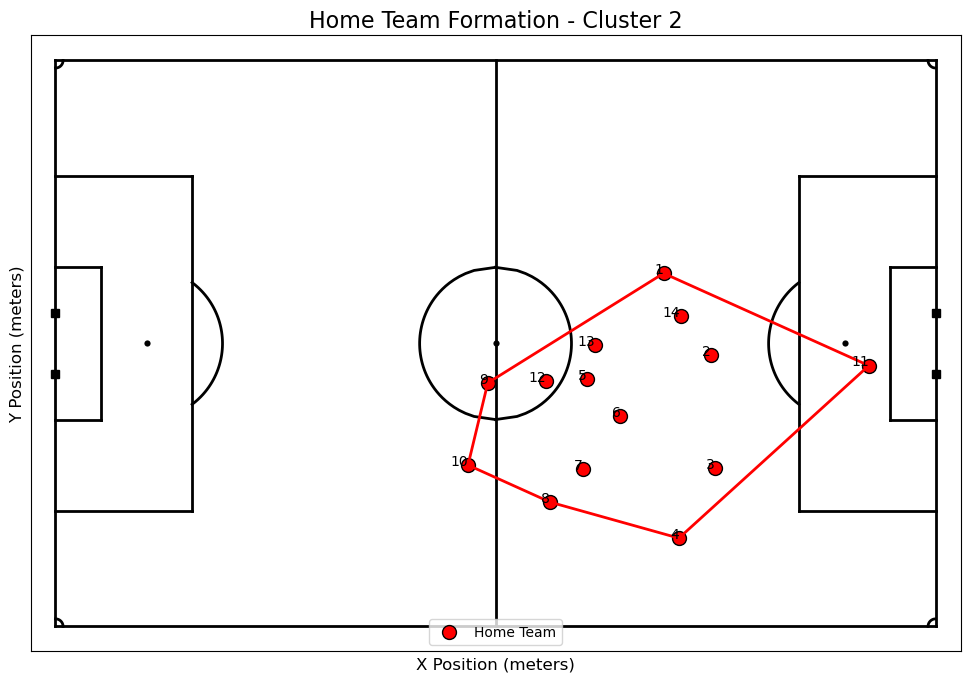

Goalkeeper identified: Player 25 (Column: Away_25_x)
Cluster data shape for cluster 2: (22441, 29)
Player columns: ['Away_25_x', 'Away_25_y', 'Away_15_x', 'Away_15_y', 'Away_16_x', 'Away_16_y', 'Away_17_x', 'Away_17_y', 'Away_18_x', 'Away_18_y', 'Away_19_x', 'Away_19_y', 'Away_20_x', 'Away_20_y', 'Away_21_x', 'Away_21_y', 'Away_22_x', 'Away_22_y', 'Away_23_x', 'Away_23_y', 'Away_24_x', 'Away_24_y', 'Away_26_x', 'Away_26_y', 'ball_x', 'ball_y']
Processing player 25 - X: -28.973677566062122, Y: -0.307390089568201
Processing player 15 - X: 25.570963115725682, Y: -13.444993028831155
Processing player 16 - X: 20.532284125484605, Y: -4.455211097544672
Processing player 17 - X: 15.393846669934492, Y: 3.2327218484024773
Processing player 18 - X: 21.367790900583753, Y: 11.265004267189518
Processing player 19 - X: 33.169526612896036, Y: 1.4986057020631876
Processing player 20 - X: 31.549405013145584, Y: 3.647552756116037
Processing player 21 - X: 26.61016007842788, Y: 0.5580193146472974
Processi

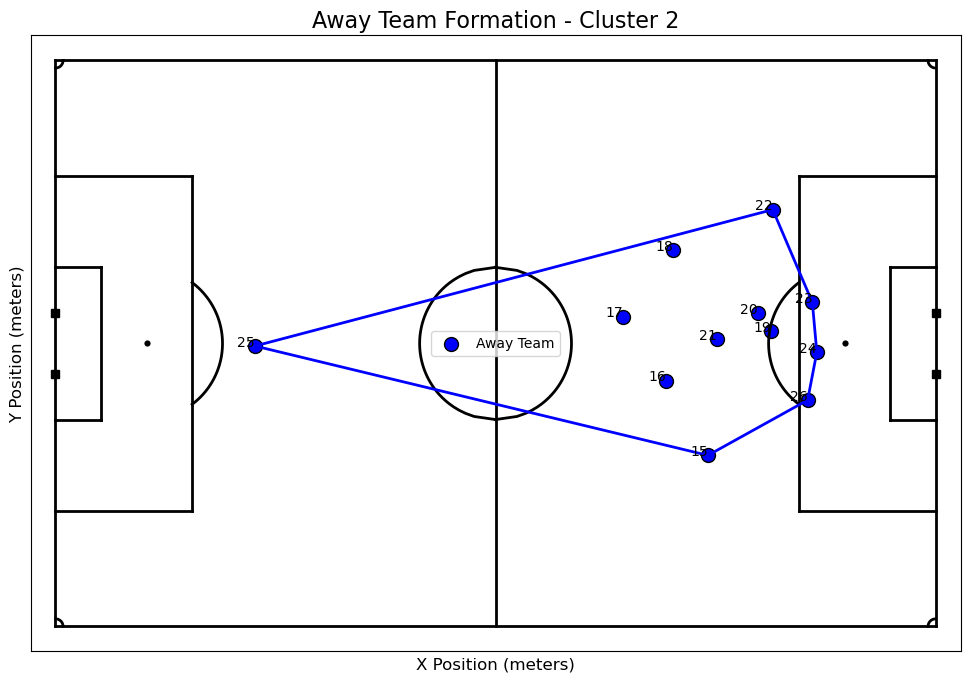

In [48]:
# Plot separate formations for Home & Away teams
for i in range(3):  # Change to desired number of clusters
    plot_team_formation(tracking_home, i, "Home Team", "red")
    plot_team_formation(tracking_away, i, "Away Team", "blue")

In [26]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y,ball_x,ball_y,formation_cluster
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1,0.08,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1,0.12,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1,0.16,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1,0.20,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,-7.56364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,NaN,9.71278,-24.17468,-1.09392,30.29672,23.36028,-9.04400,NaN,NaN,2
141153,2,5646.12,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,NaN,9.71278,-24.17468,-1.09286,30.34568,23.31046,-9.03176,NaN,NaN,2
141154,2,5646.16,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,NaN,9.71278,-24.17468,-1.09074,30.40348,23.28714,-9.02632,NaN,NaN,2


In [27]:
home_avg_positions


Home_11_x    39.716046
Home_11_y     0.044372
Home_1_x      8.440648
Home_1_y     13.897381
Home_2_x     15.017162
Home_2_y      6.357901
Home_3_x     15.001056
Home_3_y     -5.494028
Home_4_x     12.503462
Home_4_y    -14.318497
Home_5_x      1.828732
Home_5_y      3.148120
Home_6_x      6.036646
Home_6_y      0.843745
Home_7_x      2.706434
Home_7_y     -5.615551
Home_8_x     -3.407183
Home_8_y    -11.725271
Home_9_x     -7.664369
Home_9_y      3.075784
Home_10_x   -11.642392
Home_10_y    -4.581938
Home_12_x    -0.678142
Home_12_y     8.561785
Home_13_x     6.540521
Home_13_y     4.896060
Home_14_x    13.021101
Home_14_y    15.378184
ball_x       -1.558624
ball_y       -0.842413
dtype: float64